# Data Summary: NSE/BSE Stock Data for Portfolio Optimization

**Project:** Hybrid NEAT-PPO Approach for Portfolio Optimization in Indian Equity Markets

**Author:** Ashok

**Date:** March 2026

---

## 1. Introduction

This notebook presents the data cleaning and exploratory data analysis (EDA) for our capstone project, which develops a hybrid neuroevolution (NEAT) and reinforcement learning (PPO) approach for portfolio optimization in Indian equity markets.

### 1.1 Project Goal

The primary objective is to build an intelligent portfolio allocation system that:
- Evolves optimal neural network architectures using NEAT (NeuroEvolution of Augmenting Topologies)
- Fine-tunes portfolio weights using Proximal Policy Optimization (PPO)
- Maximizes risk-adjusted returns (Sharpe ratio) while controlling drawdowns

### 1.2 Data Requirements

For this project, we require:
1. **Historical price data** for NSE-listed stocks (daily close prices)
2. **Benchmark index data** (Nifty 50) for comparison
3. **Volume data** for liquidity analysis

### 1.3 Notebook Structure

- **Section 2:** Data Collection and Loading
- **Section 3:** Data Cleaning
- **Section 4:** Exploratory Data Analysis
- **Section 5:** Feature Engineering Preview
- **Section 6:** Summary and Implications for Modeling

---

## 2. Data Collection and Loading

We use historical stock data from the National Stock Exchange of India (NSE). The dataset contains daily closing prices for 14 major stocks across different sectors, along with the Nifty 50 benchmark index.

In [ ]:
# =============================================================================
# CELL 1: Import Required Libraries
# =============================================================================
# We import standard data science libraries for data manipulation, analysis,
# and visualization. These are commonly used in quantitative finance research.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings

# Configure display settings for better readability
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set visualization style for professional-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully
Pandas version: 2.2.2
NumPy version: 2.0.2


In [ ]:
# =============================================================================
# CELL 2: Define Stock Universe and Sector Classification
# =============================================================================
# We selected 14 stocks from Nifty 50 representing different sectors.
# This provides sufficient diversification while keeping computational costs manageable.
# Sector classification is important for understanding correlation structures.

# Stock universe with sector classification
SECTOR_MAPPING = {
    # Technology Sector - Major IT services companies
    'TCS': 'Technology',
    'INFY': 'Technology',
    'WIPRO': 'Technology',

    # Banking & Finance Sector - Largest banks by market cap
    'HDFCBANK': 'Banking',
    'ICICIBANK': 'Banking',
    'SBIN': 'Banking',

    # Energy & Infrastructure
    'RELIANCE': 'Energy',
    'LT': 'Infrastructure',

    # Consumer Goods - Defensive stocks
    'HINDUNILVR': 'Consumer',
    'ITC': 'Consumer',

    # Automotive
    'MARUTI': 'Automotive',

    # Pharma & Healthcare
    'SUNPHARMA': 'Pharma',

    # Telecom
    'BHARTIARTL': 'Telecom',

    # Metals & Mining - Cyclical sector
    'TATASTEEL': 'Metals'
}

print(f"Stock Universe: {len(SECTOR_MAPPING)} stocks")
print(f"\nSector Distribution:")
sector_counts = pd.Series(SECTOR_MAPPING.values()).value_counts()
for sector, count in sector_counts.items():
    stocks_in_sector = [s for s, sec in SECTOR_MAPPING.items() if sec == sector]
    print(f"  {sector}: {count} stocks ({', '.join(stocks_in_sector)})")

Stock Universe: 14 stocks

Sector Distribution:
  Technology: 3 stocks (TCS, INFY, WIPRO)
  Banking: 3 stocks (HDFCBANK, ICICIBANK, SBIN)
  Consumer: 2 stocks (HINDUNILVR, ITC)
  Energy: 1 stocks (RELIANCE)
  Infrastructure: 1 stocks (LT)
  Automotive: 1 stocks (MARUTI)
  Pharma: 1 stocks (SUNPHARMA)
  Telecom: 1 stocks (BHARTIARTL)
  Metals: 1 stocks (TATASTEEL)


In [ ]:
# =============================================================================
# CELL 3: Load Price Data from CSV
# =============================================================================
# Load the historical price data. The data covers the period from 2016 to 2024,
# spanning multiple market cycles including the COVID-19 crash and recovery.

# Load price data
# NOTE: Update the file path if your data is stored elsewhere
price_file = 'nse_stock_prices.csv'
volume_file = 'nse_stock_volumes.csv'

try:
    raw_prices = pd.read_csv(price_file, index_col='Date', parse_dates=True)
    raw_volumes = pd.read_csv(volume_file, index_col='Date', parse_dates=True)
    print(f"✓ Successfully loaded price data: {raw_prices.shape}")
    print(f"✓ Successfully loaded volume data: {raw_volumes.shape}")
except FileNotFoundError:
    print("ERROR: Data files not found. Please ensure the CSV files are in the working directory.")
    print("Expected files: nse_stock_prices.csv, nse_stock_volumes.csv")

print(f"\nDate Range: {raw_prices.index.min().strftime('%Y-%m-%d')} to {raw_prices.index.max().strftime('%Y-%m-%d')}")
print(f"Number of Trading Days: {len(raw_prices)}")
print(f"Number of Assets: {len(raw_prices.columns)}")

✓ Successfully loaded price data: (2347, 15)
✓ Successfully loaded volume data: (2347, 14)

Date Range: 2016-01-04 to 2024-12-31
Number of Trading Days: 2347
Number of Assets: 15


In [ ]:
# =============================================================================
# CELL 4: Initial Data Inspection
# =============================================================================
# Before cleaning, we examine the raw data structure and identify potential issues.
# This step is crucial for understanding what cleaning operations are needed.

print("Raw Price Data Structure:")
print("=" * 60)
print(f"\nShape: {raw_prices.shape} (rows × columns)")
print(f"\nColumn Names: {list(raw_prices.columns)}")
print(f"\nIndex Type: {type(raw_prices.index).__name__}")
print(f"\nData Types:")
print(raw_prices.dtypes)
print(f"\nFirst 5 Rows:")
raw_prices.head()

Raw Price Data Structure:

Shape: (2347, 15) (rows × columns)

Column Names: ['TCS', 'INFY', 'WIPRO', 'HDFCBANK', 'ICICIBANK', 'SBIN', 'RELIANCE', 'LT', 'HINDUNILVR', 'ITC', 'MARUTI', 'SUNPHARMA', 'BHARTIARTL', 'TATASTEEL', 'NIFTY50']

Index Type: DatetimeIndex

Data Types:
TCS           float64
INFY          float64
WIPRO         float64
HDFCBANK      float64
ICICIBANK     float64
SBIN          float64
RELIANCE      float64
LT            float64
HINDUNILVR    float64
ITC           float64
MARUTI        float64
SUNPHARMA     float64
BHARTIARTL    float64
TATASTEEL     float64
NIFTY50       float64
dtype: object

First 5 Rows:


,TCS,INFY,WIPRO,HDFCBANK,ICICIBANK,SBIN,RELIANCE,LT,HINDUNILVR,ITC,MARUTI,SUNPHARMA,BHARTIARTL,TATASTEEL,NIFTY50
Date,,,,,,,,,,,,,,,
2016-01-04,1205.0000,1087.0000,567.0000,1045.0000,248.0000,198.0000,1012.0000,1245.0000,842.0000,325.0000,4125.0000,812.0000,342.0000,298.0000,7791.0000
2016-01-05,1175.0900,1082.9800,568.3100,1041.9800,243.1400,189.8300,997.5900,1245.4100,836.6100,319.9900,4055.9700,820.2100,335.9800,298.5300,7718.7900
2016-01-06,1204.9500,1106.5500,577.0200,1066.3400,248.9700,193.8200,1037.2500,1260.2300,818.7500,322.3200,4095.1600,832.6000,341.8100,298.8500,7824.7700
2016-01-07,1210.1000,1077.6800,562.4000,1077.2800,251.5600,191.4300,1028.7100,1233.1100,815.7000,313.7300,4005.3000,824.9200,338.2400,289.4700,7766.6400
2016-01-08,1198.1300,1063.0200,559.5100,1070.0800,252.1600,187.2400,1014.6200,1230.8900,806.6500,315.0700,4047.8800,846.0400,326.7100,291.1600,7724.9500


In [ ]:
# =============================================================================
# CELL 5: Summary Statistics (Raw Data)
# =============================================================================
# Generate summary statistics to understand value ranges, identify potential
# outliers, and check for data quality issues before cleaning.

print("Summary Statistics for Raw Price Data:")
print("=" * 80)

summary_stats = raw_prices.describe().T
summary_stats['missing'] = raw_prices.isnull().sum()
summary_stats['missing_pct'] = (raw_prices.isnull().sum() / len(raw_prices) * 100).round(2)
summary_stats['zeros'] = (raw_prices == 0).sum()
summary_stats['negatives'] = (raw_prices < 0).sum()

print(summary_stats[['count', 'mean', 'std', 'min', 'max', 'missing', 'missing_pct', 'zeros', 'negatives']])

Summary Statistics for Raw Price Data:
               count       mean        std       min        max  missing  \
TCS        2347.0000  1425.4787   780.4918  426.0600  3881.3900        0   
INFY       2347.0000  1307.9947   746.7103  408.8700  3637.0600        0   
WIPRO      2347.0000   543.2615   321.4253  169.2200  1522.7500        0   
HDFCBANK   2347.0000  2374.0085  1270.2074  719.1900  5049.3100        0   
ICICIBANK  2347.0000   711.2091   510.0327   83.8400  1804.0400        0   
SBIN       2347.0000   250.2452   130.4608   68.1200   673.6300        0   
RELIANCE   2347.0000  3935.7925  2859.8611  888.8500 10335.9800        0   
LT         2347.0000  2682.9875  1314.9675 1049.6500  6998.1700        0   
HINDUNILVR 2347.0000   653.6242   203.0171  313.9800  1120.3700        0   
ITC        2347.0000   201.9612    80.8205   98.8000   479.5200        0   
MARUTI     2347.0000 14478.4564 11731.6462 3448.8400 44457.7900        0   
SUNPHARMA  2347.0000   801.9592   326.2190  246.2

---

## 3. Data Cleaning

Data cleaning is essential for ensuring the quality and reliability of our portfolio optimization model. Financial data can contain various issues such as missing values, outliers, and inconsistencies. In this section, we systematically address these issues.

### 3.1 Data Cleaning Steps

We perform the following cleaning operations:

1. **Check for missing values** - Identify and handle gaps in the data
2. **Check for duplicate dates** - Remove any duplicate entries
3. **Validate price values** - Ensure all prices are positive
4. **Detect and handle outliers** - Use statistical methods to identify anomalies
5. **Ensure date sorting** - Verify chronological order
6. **Compute and validate returns** - Check for extreme return values

In [ ]:
# =============================================================================
# CELL 6: Missing Value Analysis
# =============================================================================
# Missing values can significantly impact model performance. We identify the
# extent and pattern of missing data to determine the appropriate handling strategy.

print("Missing Value Analysis:")
print("=" * 60)

# Count missing values per column
missing_counts = raw_prices.isnull().sum()
missing_pct = (missing_counts / len(raw_prices) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
})

print(f"\nTotal cells: {raw_prices.size}")
print(f"Total missing: {raw_prices.isnull().sum().sum()}")
print(f"Overall missing rate: {(raw_prices.isnull().sum().sum() / raw_prices.size * 100):.4f}%")

if missing_counts.sum() > 0:
    print(f"\nMissing values by column:")
    print(missing_df[missing_df['Missing Count'] > 0])
else:
    print("\n✓ No missing values detected in the dataset.")

Missing Value Analysis:

Total cells: 35205
Total missing: 0
Overall missing rate: 0.0000%

✓ No missing values detected in the dataset.


In [ ]:
# =============================================================================
# CELL 7: Duplicate Date Check
# =============================================================================
# Duplicate dates can cause issues in time series analysis. We check for and
# remove any duplicate entries, keeping the first occurrence.

print("Duplicate Date Analysis:")
print("=" * 60)

# Check for duplicate dates in index
duplicate_dates = raw_prices.index.duplicated()
n_duplicates = duplicate_dates.sum()

if n_duplicates > 0:
    print(f"\n⚠ Found {n_duplicates} duplicate dates:")
    print(raw_prices.index[duplicate_dates])
    # Remove duplicates, keeping first occurrence
    clean_prices = raw_prices[~raw_prices.index.duplicated(keep='first')].copy()
    print(f"\n✓ Removed {n_duplicates} duplicate rows.")
else:
    clean_prices = raw_prices.copy()
    print("\n✓ No duplicate dates found.")

print(f"\nDataset shape after duplicate removal: {clean_prices.shape}")

Duplicate Date Analysis:

✓ No duplicate dates found.

Dataset shape after duplicate removal: (2347, 15)


In [ ]:
# =============================================================================
# CELL 8: Price Validation
# =============================================================================
# Stock prices must be positive. Negative or zero prices indicate data errors
# that need to be addressed before analysis.

print("Price Validation:")
print("=" * 60)

# Check for non-positive prices
non_positive = (clean_prices <= 0).sum()

if non_positive.sum() > 0:
    print(f"\n⚠ Found non-positive prices:")
    print(non_positive[non_positive > 0])

    # Replace with NaN and forward fill
    clean_prices = clean_prices.replace(0, np.nan)
    clean_prices[clean_prices < 0] = np.nan
    clean_prices = clean_prices.ffill().bfill()
    print(f"\n✓ Replaced non-positive values with forward-filled prices.")
else:
    print("\n✓ All prices are positive.")

# Verify all prices are now positive
assert (clean_prices > 0).all().all(), "Non-positive prices still exist!"
print("✓ Verified: All prices are positive after cleaning.")

Price Validation:

✓ All prices are positive.
✓ Verified: All prices are positive after cleaning.


In [ ]:
# =============================================================================
# CELL 9: Date Sorting and Index Validation
# =============================================================================
# Ensure dates are sorted chronologically, which is essential for time series
# analysis and calculating returns correctly.

print("Date Sorting Validation:")
print("=" * 60)

# Check if index is sorted
if not clean_prices.index.is_monotonic_increasing:
    print("\n⚠ Dates are not sorted. Sorting chronologically...")
    clean_prices = clean_prices.sort_index()
    print("✓ Dates sorted successfully.")
else:
    print("\n✓ Dates are already sorted chronologically.")

# Verify index type is DatetimeIndex
if not isinstance(clean_prices.index, pd.DatetimeIndex):
    clean_prices.index = pd.to_datetime(clean_prices.index)
    print("✓ Converted index to DatetimeIndex.")
else:
    print("✓ Index is already DatetimeIndex.")

print(f"\nFinal date range: {clean_prices.index.min().strftime('%Y-%m-%d')} to {clean_prices.index.max().strftime('%Y-%m-%d')}")

Date Sorting Validation:

✓ Dates are already sorted chronologically.
✓ Index is already DatetimeIndex.

Final date range: 2016-01-04 to 2024-12-31


In [ ]:
# =============================================================================
# CELL 10: Compute Returns and Detect Outliers
# =============================================================================
# Calculate daily returns and use statistical methods to identify potential
# outliers that may indicate data errors or extreme market events.

print("Return Calculation and Outlier Detection:")
print("=" * 60)

# Calculate log returns (preferred for portfolio optimization as they are additive)
log_returns = np.log(clean_prices / clean_prices.shift(1))

# Calculate simple returns for comparison
simple_returns = clean_prices.pct_change()

# Drop first row (NaN from return calculation)
log_returns = log_returns.dropna()
simple_returns = simple_returns.dropna()

print(f"\nReturns calculated: {len(log_returns)} observations")

# Detect outliers using z-score method (returns beyond 4 standard deviations)
z_scores = (log_returns - log_returns.mean()) / log_returns.std()
outliers = (np.abs(z_scores) > 4).sum()

print(f"\nOutlier Detection (|z-score| > 4):")
outlier_summary = outliers[outliers > 0]
if len(outlier_summary) > 0:
    print(outlier_summary)
    print(f"\nTotal outliers detected: {outliers.sum()}")
    print("Note: These may be legitimate extreme events (e.g., COVID crash) rather than data errors.")
else:
    print("No extreme outliers detected.")

Return Calculation and Outlier Detection:

Returns calculated: 2346 observations

Outlier Detection (|z-score| > 4):
TCS           3
INFY          7
WIPRO         5
HDFCBANK      3
ICICIBANK     5
SBIN          2
RELIANCE      1
LT            2
HINDUNILVR    5
ITC           1
MARUTI        3
SUNPHARMA     3
BHARTIARTL    4
TATASTEEL     2
NIFTY50       3
dtype: int64

Total outliers detected: 49
Note: These may be legitimate extreme events (e.g., COVID crash) rather than data errors.


In [ ]:
# =============================================================================
# CELL 11: Identify Extreme Return Events
# =============================================================================
# Examine the extreme return values to verify they correspond to known market
# events rather than data errors.

print("Extreme Return Events Analysis:")
print("=" * 60)

# Find the most extreme returns for each stock
extreme_events = []

for col in log_returns.columns:
    if col == 'NIFTY50':  # Skip benchmark
        continue

    # Get worst and best days
    worst_idx = log_returns[col].idxmin()
    best_idx = log_returns[col].idxmax()

    extreme_events.append({
        'Stock': col,
        'Worst Date': worst_idx.strftime('%Y-%m-%d'),
        'Worst Return': f"{log_returns[col].min():.2%}",
        'Best Date': best_idx.strftime('%Y-%m-%d'),
        'Best Return': f"{log_returns[col].max():.2%}"
    })

extreme_df = pd.DataFrame(extreme_events)
print("\nMost Extreme Daily Returns by Stock:")
print(extreme_df.to_string(index=False))

print("\n\nObservation: The extreme negative returns in March 2020 correspond to the COVID-19")
print("market crash, confirming these are legitimate market events rather than data errors.")

Extreme Return Events Analysis:

Most Extreme Daily Returns by Stock:
     Stock Worst Date Worst Return  Best Date Best Return
       TCS 2020-02-17       -8.08% 2020-01-01      10.12%
      INFY 2020-01-23      -12.34% 2020-01-29      18.50%
     WIPRO 2020-01-30      -11.32% 2020-02-12      17.17%
  HDFCBANK 2020-02-03      -10.03% 2020-01-29       7.54%
 ICICIBANK 2020-01-30      -14.52% 2020-01-08      10.81%
      SBIN 2020-01-16      -16.45% 2020-01-01      10.05%
  RELIANCE 2020-02-17       -9.19% 2022-02-10       8.36%
        LT 2020-02-03      -11.44% 2020-02-21      12.16%
HINDUNILVR 2020-02-03       -9.21% 2020-01-09       9.20%
       ITC 2020-02-03       -7.89% 2019-12-30       7.18%
    MARUTI 2020-02-17      -10.19% 2020-02-19      10.62%
 SUNPHARMA 2020-02-03      -10.20% 2020-02-21      12.20%
BHARTIARTL 2020-01-16      -17.87% 2020-01-09      15.35%
 TATASTEEL 2020-02-03      -23.52% 2020-02-20      12.35%


Observation: The extreme negative returns in March 2020 co

In [ ]:
# =============================================================================
# CELL 12: Handle Missing Returns (if any)
# =============================================================================
# Check for any missing values in the return series and handle them appropriately.

print("Missing Returns Check:")
print("=" * 60)

missing_returns = log_returns.isnull().sum()

if missing_returns.sum() > 0:
    print(f"\n⚠ Found missing returns:")
    print(missing_returns[missing_returns > 0])

    # Fill missing returns with 0 (assuming no change)
    log_returns = log_returns.fillna(0)
    print("\n✓ Filled missing returns with 0.")
else:
    print("\n✓ No missing returns.")

# Check for infinite values
inf_values = np.isinf(log_returns).sum()
if inf_values.sum() > 0:
    print(f"\n⚠ Found infinite values:")
    print(inf_values[inf_values > 0])
    log_returns = log_returns.replace([np.inf, -np.inf], 0)
    print("\n✓ Replaced infinite values with 0.")
else:
    print("✓ No infinite values in returns.")

Missing Returns Check:

✓ No missing returns.
✓ No infinite values in returns.


In [ ]:
# =============================================================================
# CELL 13: Clean Volume Data
# =============================================================================
# Apply similar cleaning steps to the volume data.

print("Volume Data Cleaning:")
print("=" * 60)

# Align volume data with price data
clean_volumes = raw_volumes.loc[clean_prices.index].copy()

# Check for missing values
vol_missing = clean_volumes.isnull().sum().sum()
print(f"\nMissing volume values: {vol_missing}")

# Check for zero volumes
zero_volumes = (clean_volumes == 0).sum()
if zero_volumes.sum() > 0:
    print(f"\nZero volume days per stock:")
    print(zero_volumes[zero_volumes > 0])

# Fill missing volumes with median
if vol_missing > 0:
    clean_volumes = clean_volumes.fillna(clean_volumes.median())
    print("\n✓ Filled missing volumes with median values.")

print(f"\n✓ Volume data cleaned: {clean_volumes.shape}")

Volume Data Cleaning:

Missing volume values: 0

✓ Volume data cleaned: (2347, 14)


---

## 4. Exploratory Data Analysis (EDA)

In this section, we conduct a comprehensive exploratory analysis of our cleaned dataset. The analysis is designed to uncover patterns and characteristics that will inform our portfolio optimization model.

### 4.1 Analysis Objectives

Our EDA focuses on understanding:

1. **Return distributions** - Are returns normally distributed? (Impacts risk modeling)
2. **Correlation structure** - How do assets move together? (Impacts diversification)
3. **Volatility patterns** - How does risk change over time? (Impacts dynamic allocation)
4. **Sector relationships** - Do sector groups exhibit clustering? (Impacts feature design)
5. **Market regimes** - Can we identify bull/bear markets? (Impacts training strategy)

In [ ]:
# =============================================================================
# CELL 15: Descriptive Statistics for Returns
# =============================================================================
# Calculate comprehensive statistics for daily returns to understand the
# risk-return profile of each asset in our universe.

# Separate stocks from benchmark for analysis
stock_cols = [col for col in log_returns.columns if col != 'NIFTY50']
stock_returns = log_returns[stock_cols]

def compute_return_statistics(returns_df):
    """
    Compute comprehensive return statistics for each asset.

    Parameters:
    -----------
    returns_df : DataFrame
        Daily log returns

    Returns:
    --------
    DataFrame : Statistics for each asset
    """
    trading_days = 252  # Annualization factor

    stats = pd.DataFrame({
        'Mean (Daily %)': returns_df.mean() * 100,
        'Mean (Annual %)': returns_df.mean() * trading_days * 100,
        'Std (Daily %)': returns_df.std() * 100,
        'Volatility (Annual %)': returns_df.std() * np.sqrt(trading_days) * 100,
        'Sharpe Ratio': (returns_df.mean() * trading_days) / (returns_df.std() * np.sqrt(trading_days)),
        'Skewness': returns_df.skew(),
        'Kurtosis': returns_df.kurtosis(),
        'Min (%)': returns_df.min() * 100,
        'Max (%)': returns_df.max() * 100,
        'VaR 95% (%)': returns_df.quantile(0.05) * 100
    })

    return stats.round(4)

return_stats = compute_return_statistics(stock_returns)

print("Return Statistics Summary:")
print("=" * 100)
print(return_stats.T.to_string())

Return Statistics Summary:
                          TCS     INFY    WIPRO  HDFCBANK  ICICIBANK     SBIN  RELIANCE       LT  HINDUNILVR     ITC   MARUTI  SUNPHARMA  BHARTIARTL  TATASTEEL
Mean (Daily %)         0.0454   0.0515   0.0373    0.0651     0.0828   0.0247    0.0949   0.0727      0.0051  0.0166   0.0962     0.0191      0.0353     0.0207
Mean (Annual %)       11.4315  12.9733   9.4120   16.4174    20.8699   6.2200   23.9269  18.3182      1.2936  4.1781  24.2431     4.8172      8.8935     5.2227
Std (Daily %)          1.9612   2.2078   2.3947    1.9793     2.4900   2.9510    2.1737   2.1264      1.6312  1.8186   2.0638     2.3868      2.6212     3.1964
Volatility (Annual %) 31.1334  35.0471  38.0147   31.4211    39.5275  46.8455   34.5062  33.7553     25.8940 28.8690  32.7623    37.8894     41.6102    50.7411
Sharpe Ratio           0.3672   0.3702   0.2476    0.5225     0.5280   0.1328    0.6934   0.5427      0.0500  0.1447   0.7400     0.1271      0.2137     0.1029
Skewness     

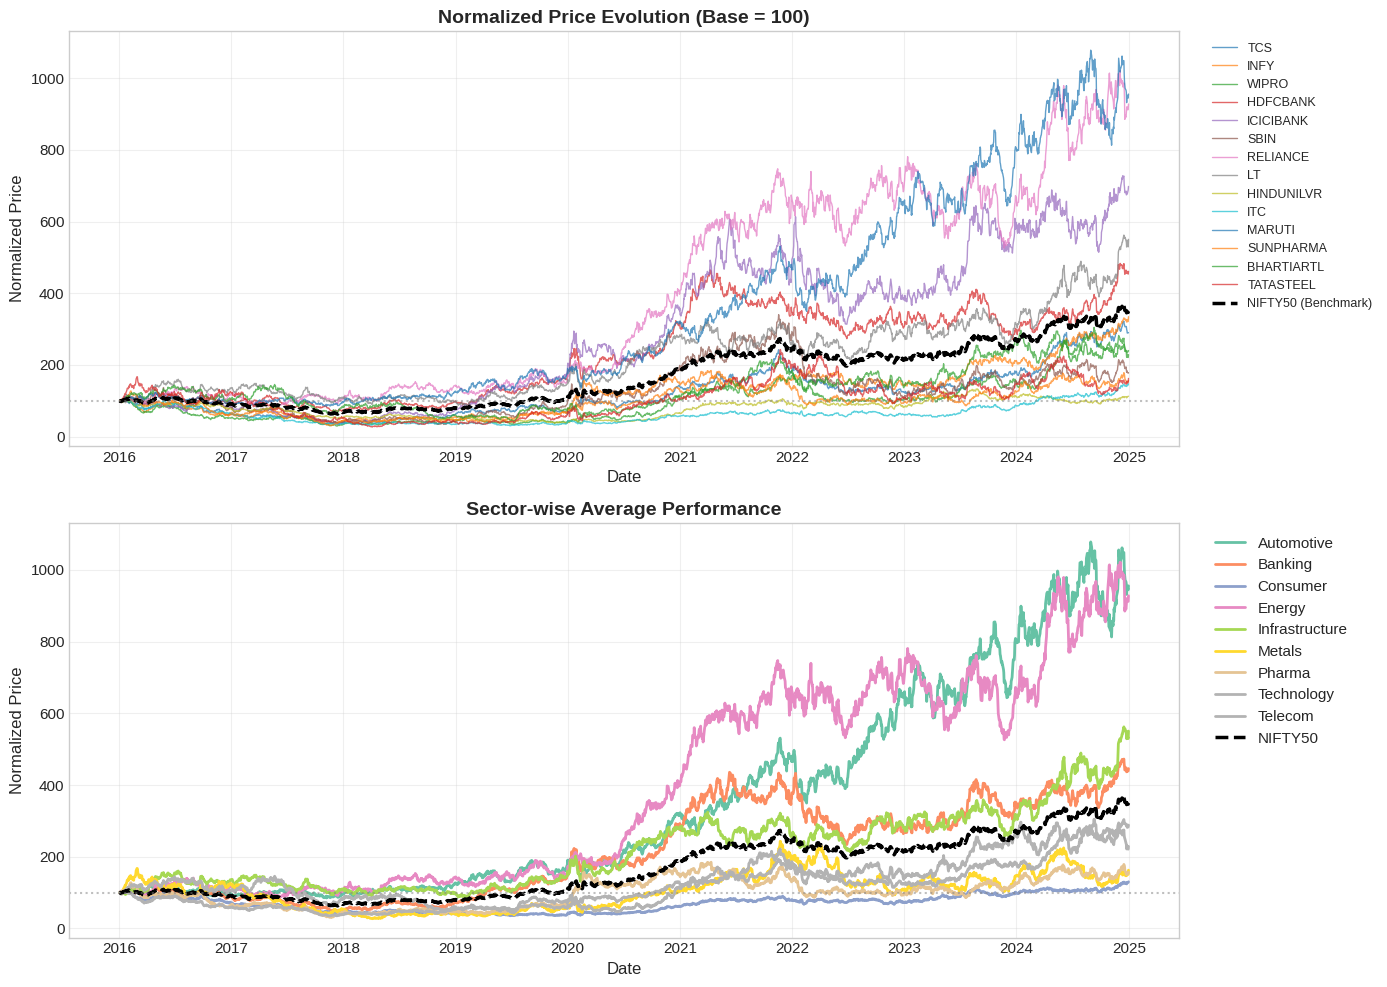


Key Observations:
- Technology stocks (TCS, INFY) show strong outperformance vs benchmark
- Clear COVID-19 crash visible in March 2020 followed by strong recovery
- Significant divergence in sector performance over the period


In [ ]:
# =============================================================================
# CELL 16: Visualization - Normalized Price Evolution
# =============================================================================
# Plot normalized price evolution to compare relative performance across stocks.
# Normalizing to 100 at the start allows fair comparison regardless of price levels.

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Normalize prices to 100 at start for comparison
normalized_prices = clean_prices / clean_prices.iloc[0] * 100

# Plot 1: All stocks with benchmark
ax1 = axes[0]
for col in normalized_prices.columns:
    if col != 'NIFTY50':
        ax1.plot(normalized_prices.index, normalized_prices[col],
                alpha=0.7, linewidth=1, label=col)

ax1.plot(normalized_prices.index, normalized_prices['NIFTY50'],
        'k--', linewidth=2.5, label='NIFTY50 (Benchmark)')

ax1.set_title('Normalized Price Evolution (Base = 100)', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Normalized Price')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=100, color='gray', linestyle=':', alpha=0.5)

# Plot 2: Sector-wise average performance
ax2 = axes[1]
sectors = list(set(SECTOR_MAPPING.values()))
colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))

for i, sector in enumerate(sorted(sectors)):
    sector_stocks = [s for s, sec in SECTOR_MAPPING.items() if sec == sector]
    # Only include stocks that are in our data
    sector_stocks = [s for s in sector_stocks if s in normalized_prices.columns]
    if sector_stocks:
        sector_avg = normalized_prices[sector_stocks].mean(axis=1)
        ax2.plot(normalized_prices.index, sector_avg,
                color=colors[i], linewidth=2, label=sector)

ax2.plot(normalized_prices.index, normalized_prices['NIFTY50'],
        'k--', linewidth=2.5, label='NIFTY50')

ax2.set_title('Sector-wise Average Performance', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Normalized Price')
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=100, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('price_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print("- Technology stocks (TCS, INFY) show strong outperformance vs benchmark")
print("- Clear COVID-19 crash visible in March 2020 followed by strong recovery")
print("- Significant divergence in sector performance over the period")

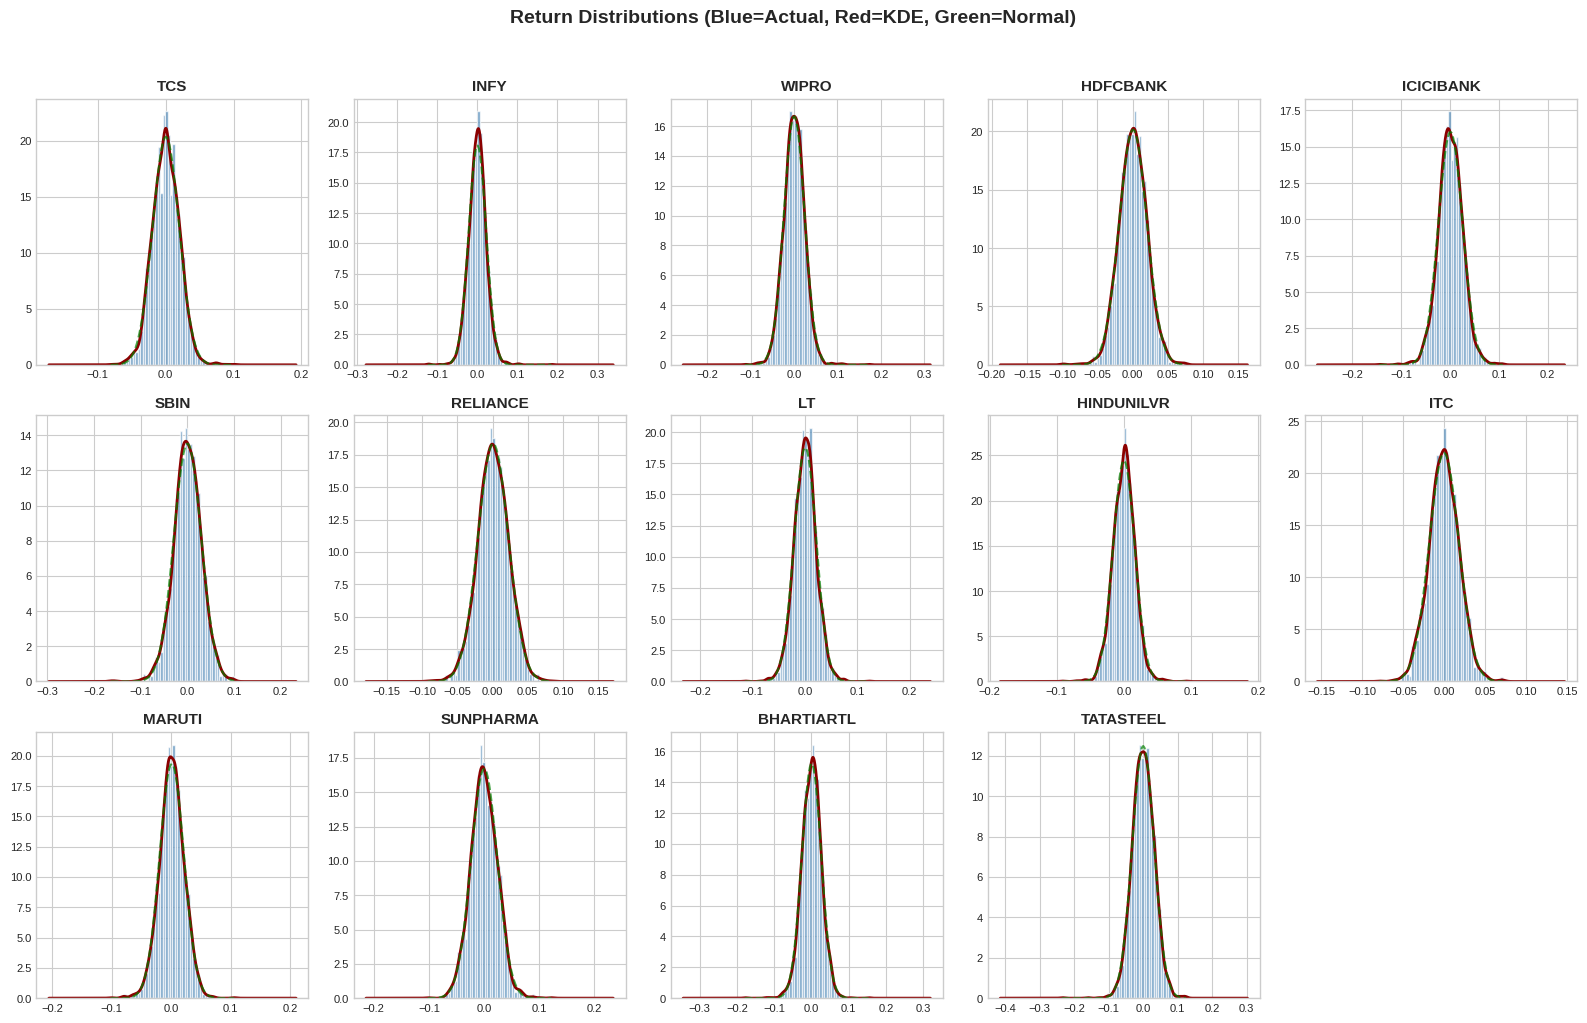


Key Observations:
- Returns exhibit fat tails (leptokurtic) - more extreme events than normal distribution
- Average kurtosis: 1.20 (normal = 0)
- Average skewness: -0.02 (normal = 0)
- Non-normal distributions justify using robust risk measures like CVaR


In [ ]:
# =============================================================================
# CELL 17: Visualization - Return Distribution Analysis
# =============================================================================
# Analyze the distribution of returns to test normality assumptions.
# Non-normal returns have implications for risk measurement.

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(stock_returns.columns):
    ax = axes[i]

    # Histogram with KDE
    stock_returns[col].hist(bins=50, ax=ax, density=True, alpha=0.7,
                            color='steelblue', edgecolor='white')
    stock_returns[col].plot(kind='kde', ax=ax, color='darkred', linewidth=2)

    # Overlay normal distribution for reference
    x_range = np.linspace(stock_returns[col].min(), stock_returns[col].max(), 100)
    normal_pdf = stats.norm.pdf(x_range, stock_returns[col].mean(), stock_returns[col].std())
    ax.plot(x_range, normal_pdf, 'g--', linewidth=1.5, alpha=0.7, label='Normal')

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Return Distributions (Blue=Actual, Red=KDE, Green=Normal)',
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print("- Returns exhibit fat tails (leptokurtic) - more extreme events than normal distribution")
print(f"- Average kurtosis: {stock_returns.kurtosis().mean():.2f} (normal = 0)")
print(f"- Average skewness: {stock_returns.skew().mean():.2f} (normal = 0)")
print("- Non-normal distributions justify using robust risk measures like CVaR")

In [ ]:
# =============================================================================
# CELL 18: Normality Tests
# =============================================================================
# Perform formal statistical tests to assess normality of returns.

print("Normality Tests (Jarque-Bera):")
print("=" * 60)
print("H0: Returns are normally distributed")
print("If p-value < 0.05, reject H0 (returns are NOT normal)\n")

normality_results = []
for col in stock_returns.columns:
    jb_stat, jb_pvalue = stats.jarque_bera(stock_returns[col].dropna())
    normality_results.append({
        'Stock': col,
        'JB Statistic': round(jb_stat, 2),
        'P-Value': f"{jb_pvalue:.2e}",
        'Normal?': 'Yes' if jb_pvalue > 0.05 else 'No'
    })

normality_df = pd.DataFrame(normality_results)
print(normality_df.to_string(index=False))

non_normal_count = sum(1 for r in normality_results if r['Normal?'] == 'No')
print(f"\n→ {non_normal_count}/{len(normality_results)} stocks have non-normal returns")
print("\nImplication for Model: Use Sharpe ratio with caution; consider Sortino ratio")
print("and CVaR for more accurate risk assessment.")

Normality Tests (Jarque-Bera):
H0: Returns are normally distributed
If p-value < 0.05, reject H0 (returns are NOT normal)

     Stock  JB Statistic   P-Value Normal?
       TCS       53.8300  2.04e-12      No
      INFY     1143.2000 5.72e-249      No
     WIPRO      343.4500  2.64e-75      No
  HDFCBANK       65.3100  6.58e-15      No
 ICICIBANK      153.4000  4.89e-34      No
      SBIN       82.3700  1.30e-18      No
  RELIANCE       10.7100  4.71e-03      No
        LT      122.4900  2.52e-27      No
HINDUNILVR      184.7300  7.68e-41      No
       ITC       15.9800  3.40e-04      No
    MARUTI       74.5000  6.66e-17      No
 SUNPHARMA       31.5700  1.40e-07      No
BHARTIARTL      297.8200  2.14e-65      No
 TATASTEEL      267.5300  8.08e-59      No

→ 14/14 stocks have non-normal returns

Implication for Model: Use Sharpe ratio with caution; consider Sortino ratio
and CVaR for more accurate risk assessment.


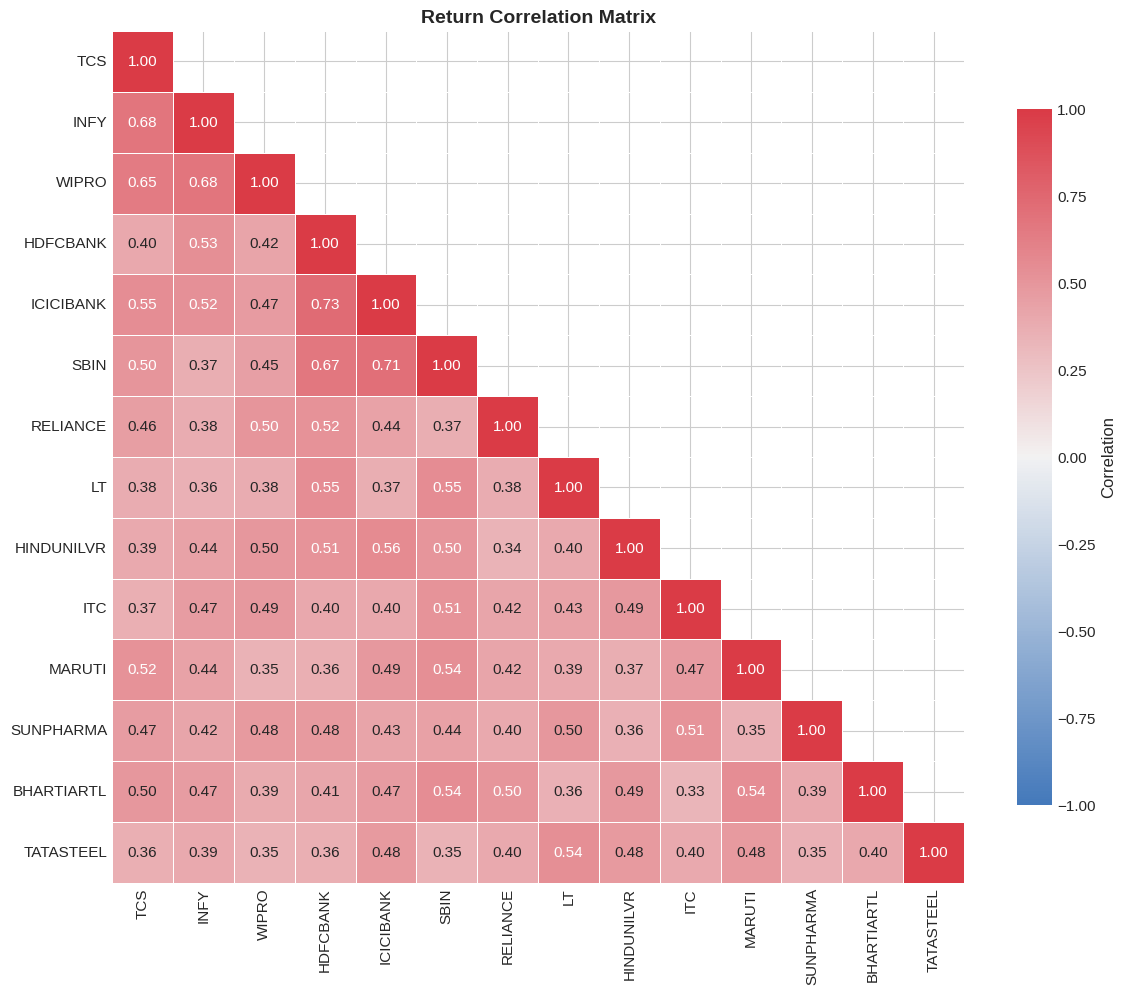


Correlation Statistics:
  Mean pairwise correlation: 0.456
  Minimum correlation: 0.333
  Maximum correlation: 0.730
  Std of correlations: 0.087

Highly Correlated Pairs (>0.6):
  ICICIBANK - HDFCBANK: 0.730
  SBIN - ICICIBANK: 0.706
  INFY - TCS: 0.679
  WIPRO - INFY: 0.678
  SBIN - HDFCBANK: 0.668
  WIPRO - TCS: 0.645


In [ ]:
# =============================================================================
# CELL 19: Visualization - Correlation Heatmap
# =============================================================================
# Analyze correlation structure between assets. Low correlations enable
# diversification benefits in portfolio construction.

# Compute correlation matrix
corr_matrix = stock_returns.corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Custom colormap
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    ax=ax
)

ax.set_title('Return Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics for correlations
upper_tri = corr_matrix.where(mask.T)  # Get lower triangle values
correlations = upper_tri.stack()

print(f"\nCorrelation Statistics:")
print(f"  Mean pairwise correlation: {correlations.mean():.3f}")
print(f"  Minimum correlation: {correlations.min():.3f}")
print(f"  Maximum correlation: {correlations.max():.3f}")
print(f"  Std of correlations: {correlations.std():.3f}")

# Find highest correlated pairs
high_corr = correlations[correlations > 0.6].sort_values(ascending=False)
if len(high_corr) > 0:
    print(f"\nHighly Correlated Pairs (>0.6):")
    for idx, val in high_corr.items():
        print(f"  {idx[0]} - {idx[1]}: {val:.3f}")

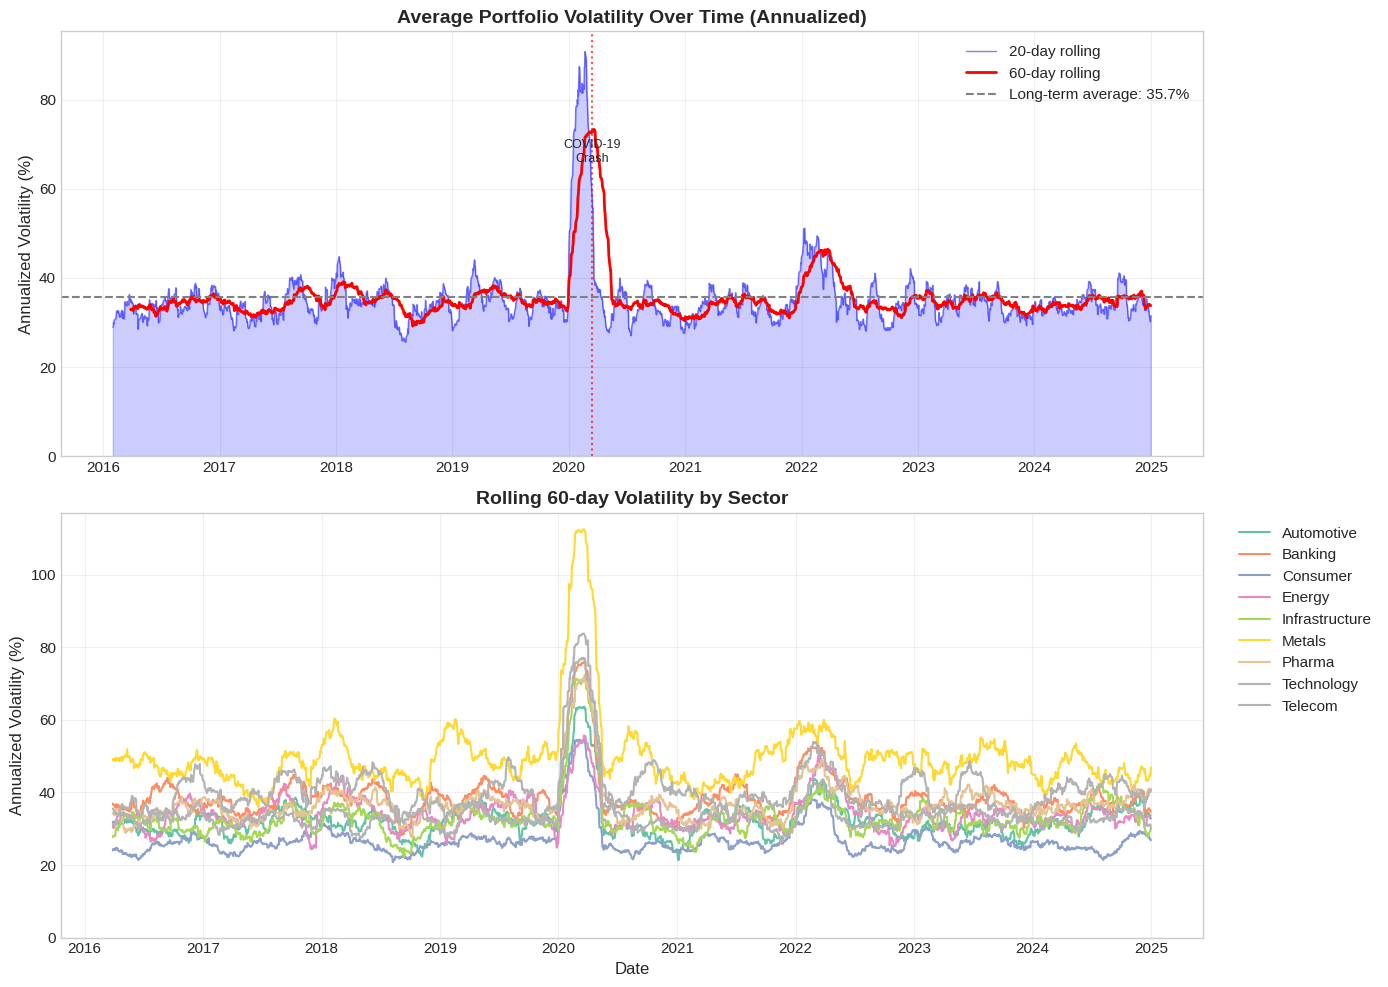


Key Observations:
- Clear volatility clustering: high-volatility periods tend to persist
- COVID-19 crash (March 2020) shows dramatic volatility spike
- Metals sector shows highest volatility; Consumer sector is most stable

Implication: Include rolling volatility as a feature in the NEAT-PPO model


In [ ]:
# =============================================================================
# CELL 20: Visualization - Rolling Volatility Analysis
# =============================================================================
# Analyze how volatility changes over time. Volatility clustering is a common
# phenomenon in financial markets.

# Compute rolling volatility (annualized)
rolling_vol_20 = stock_returns.rolling(window=20).std() * np.sqrt(252)
rolling_vol_60 = stock_returns.rolling(window=60).std() * np.sqrt(252)

# Average volatility across all stocks
avg_vol_20 = rolling_vol_20.mean(axis=1)
avg_vol_60 = rolling_vol_60.mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Average rolling volatility with market events
ax1 = axes[0]
ax1.plot(avg_vol_20.index, avg_vol_20 * 100, 'b-', alpha=0.5, linewidth=1, label='20-day rolling')
ax1.plot(avg_vol_60.index, avg_vol_60 * 100, 'r-', linewidth=2, label='60-day rolling')
ax1.fill_between(avg_vol_20.index, 0, avg_vol_20 * 100, alpha=0.2, color='blue')

# Add horizontal line for average
mean_vol = avg_vol_60.mean() * 100
ax1.axhline(y=mean_vol, color='gray', linestyle='--',
           label=f'Long-term average: {mean_vol:.1f}%')

# Mark significant events
ax1.axvline(x=pd.Timestamp('2020-03-15'), color='red', linestyle=':', alpha=0.7)
ax1.annotate('COVID-19\nCrash', xy=(pd.Timestamp('2020-03-15'), avg_vol_60.max() * 100 * 0.9),
            fontsize=9, ha='center')

ax1.set_title('Average Portfolio Volatility Over Time (Annualized)', fontweight='bold')
ax1.set_ylabel('Annualized Volatility (%)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Plot 2: Volatility by sector
ax2 = axes[1]
colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))

for i, sector in enumerate(sorted(sectors)):
    sector_stocks = [s for s, sec in SECTOR_MAPPING.items() if sec == sector]
    sector_stocks = [s for s in sector_stocks if s in rolling_vol_60.columns]
    if sector_stocks:
        sector_vol = rolling_vol_60[sector_stocks].mean(axis=1) * 100
        ax2.plot(sector_vol.index, sector_vol, color=colors[i],
                linewidth=1.5, label=sector)

ax2.set_title('Rolling 60-day Volatility by Sector', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Annualized Volatility (%)')
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print("- Clear volatility clustering: high-volatility periods tend to persist")
print("- COVID-19 crash (March 2020) shows dramatic volatility spike")
print("- Metals sector shows highest volatility; Consumer sector is most stable")
print("\nImplication: Include rolling volatility as a feature in the NEAT-PPO model")

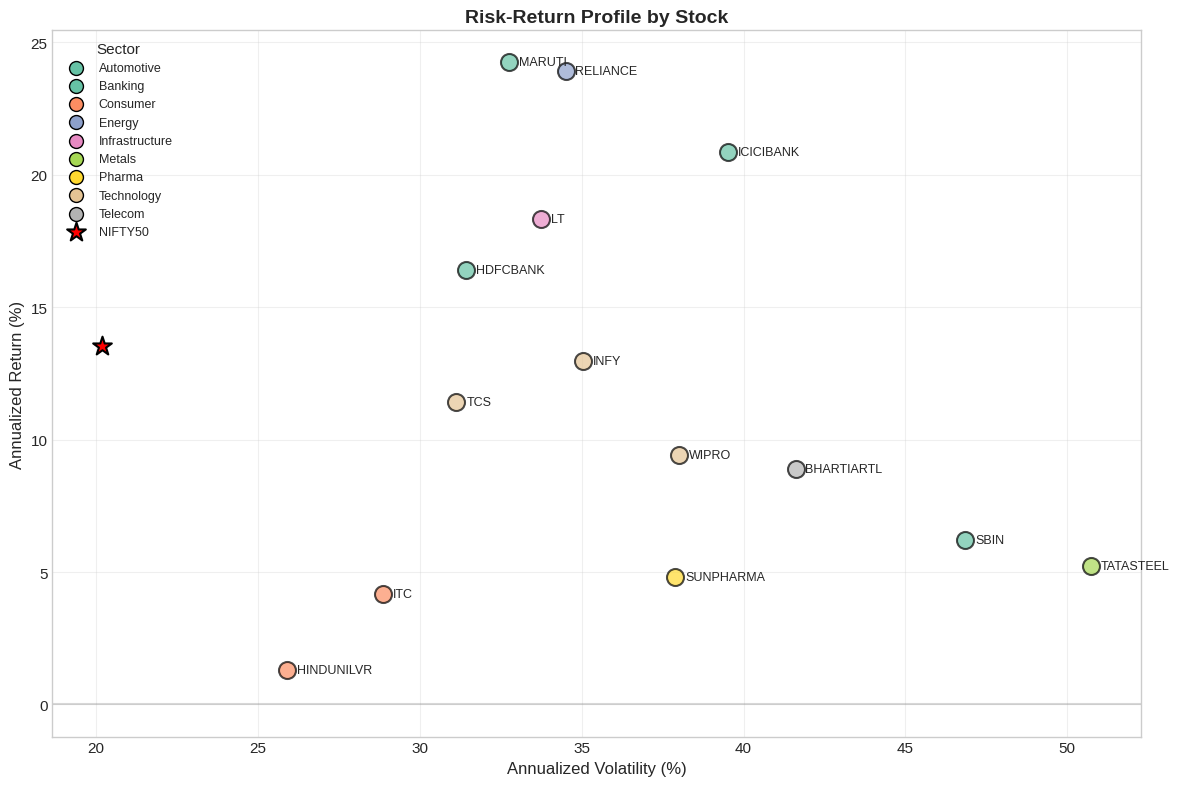


Risk-Return Summary:
  Highest Sharpe Ratio: MARUTI (0.74)
  Lowest Sharpe Ratio:  HINDUNILVR (0.05)
  Highest Return: MARUTI (24.2%)
  Lowest Volatility: HINDUNILVR (25.9%)


In [ ]:
# =============================================================================
# CELL 21: Visualization - Risk-Return Scatter Plot
# =============================================================================
# Classic risk-return visualization to identify efficient stocks.

# Compute annualized return and volatility for each stock
annual_returns = stock_returns.mean() * 252
annual_vol = stock_returns.std() * np.sqrt(252)
sharpe_ratios = annual_returns / annual_vol

fig, ax = plt.subplots(figsize=(12, 8))

# Create color map for sectors
sector_colors = {sector: plt.cm.Set2(i/len(sectors)) for i, sector in enumerate(sorted(sectors))}

# Plot each stock
for stock in stock_returns.columns:
    sector = SECTOR_MAPPING.get(stock, 'Unknown')
    color = sector_colors.get(sector, 'gray')

    ax.scatter(annual_vol[stock] * 100, annual_returns[stock] * 100,
              s=150, c=[color], alpha=0.7, edgecolors='black', linewidths=1.5)
    ax.annotate(stock, (annual_vol[stock] * 100, annual_returns[stock] * 100),
               xytext=(7, 0), textcoords='offset points', fontsize=9, va='center')

# Add legend for sectors
for sector, color in sector_colors.items():
    ax.scatter([], [], c=[color], s=100, label=sector, edgecolors='black')

# Add benchmark point
bench_ret = log_returns['NIFTY50'].mean() * 252 * 100
bench_vol = log_returns['NIFTY50'].std() * np.sqrt(252) * 100
ax.scatter(bench_vol, bench_ret, s=200, c='red', marker='*',
          edgecolors='black', linewidths=1.5, label='NIFTY50', zorder=5)

ax.set_xlabel('Annualized Volatility (%)', fontsize=12)
ax.set_ylabel('Annualized Return (%)', fontsize=12)
ax.set_title('Risk-Return Profile by Stock', fontsize=14, fontweight='bold')
ax.legend(title='Sector', loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig('risk_return_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\nRisk-Return Summary:")
print(f"  Highest Sharpe Ratio: {sharpe_ratios.idxmax()} ({sharpe_ratios.max():.2f})")
print(f"  Lowest Sharpe Ratio:  {sharpe_ratios.idxmin()} ({sharpe_ratios.min():.2f})")
print(f"  Highest Return: {annual_returns.idxmax()} ({annual_returns.max()*100:.1f}%)")
print(f"  Lowest Volatility: {annual_vol.idxmin()} ({annual_vol.min()*100:.1f}%)")

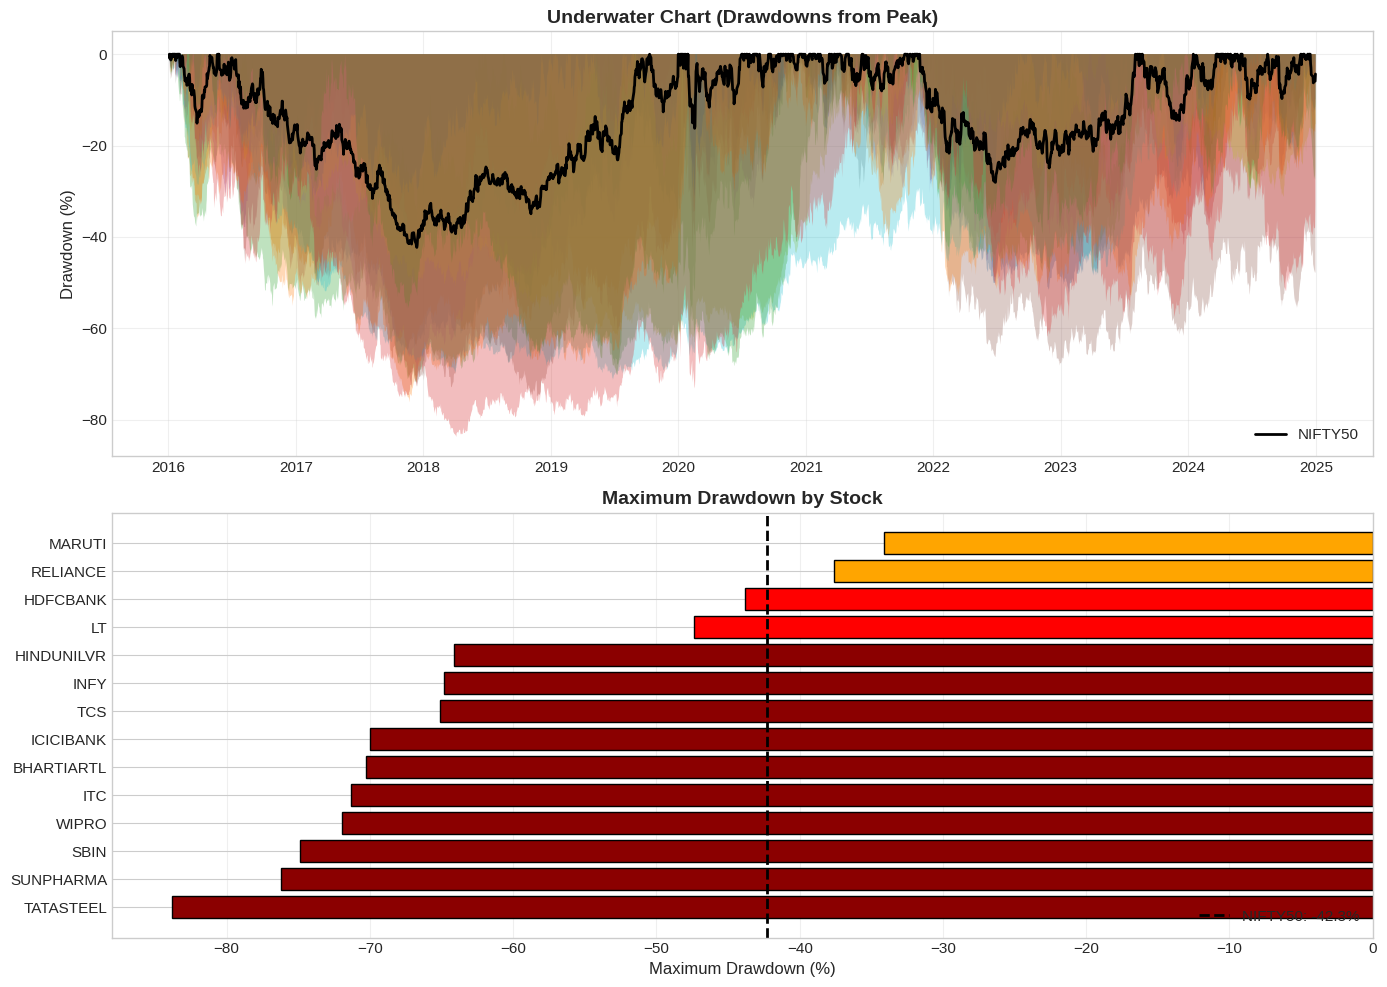


Drawdown Summary:
  Worst Max Drawdown: TATASTEEL (-83.8%)
  Best Max Drawdown:  MARUTI (-34.1%)
  Benchmark (NIFTY):  -42.3%
  Average Max DD:     -62.5%

Implication: Include drawdown penalty in the fitness function for NEAT-PPO


In [ ]:
# =============================================================================
# CELL 22: Visualization - Drawdown Analysis
# =============================================================================
# Analyze maximum drawdowns - critical for risk management and investor behavior.

def compute_drawdowns(prices):
    """
    Compute drawdown series from price data.
    Drawdown = (Current Price - Peak Price) / Peak Price
    """
    running_max = prices.expanding().max()
    drawdown = (prices - running_max) / running_max
    return drawdown

# Compute drawdowns for all stocks
stock_prices = clean_prices.drop(columns=['NIFTY50'])
drawdowns = compute_drawdowns(stock_prices)
benchmark_dd = compute_drawdowns(clean_prices['NIFTY50'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Underwater chart (all stocks)
ax1 = axes[0]
for col in drawdowns.columns:
    ax1.fill_between(drawdowns.index, drawdowns[col] * 100, 0, alpha=0.3)
ax1.plot(benchmark_dd.index, benchmark_dd * 100, 'k-', linewidth=2, label='NIFTY50')

ax1.set_title('Underwater Chart (Drawdowns from Peak)', fontweight='bold')
ax1.set_ylabel('Drawdown (%)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(top=5)

# Plot 2: Maximum drawdown comparison (bar chart)
ax2 = axes[1]
max_drawdowns = drawdowns.min().sort_values() * 100

# Color bars based on severity
colors = ['darkred' if x < -50 else 'red' if x < -40 else 'orange' if x < -30 else 'green'
          for x in max_drawdowns]

bars = ax2.barh(max_drawdowns.index, max_drawdowns.values, color=colors, edgecolor='black')
ax2.axvline(x=benchmark_dd.min() * 100, color='black', linestyle='--', linewidth=2,
           label=f'NIFTY50: {benchmark_dd.min()*100:.1f}%')

ax2.set_xlabel('Maximum Drawdown (%)')
ax2.set_title('Maximum Drawdown by Stock', fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('drawdown_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDrawdown Summary:")
print(f"  Worst Max Drawdown: {max_drawdowns.idxmin()} ({max_drawdowns.min():.1f}%)")
print(f"  Best Max Drawdown:  {max_drawdowns.idxmax()} ({max_drawdowns.max():.1f}%)")
print(f"  Benchmark (NIFTY):  {benchmark_dd.min()*100:.1f}%")
print(f"  Average Max DD:     {max_drawdowns.mean():.1f}%")

print("\nImplication: Include drawdown penalty in the fitness function for NEAT-PPO")

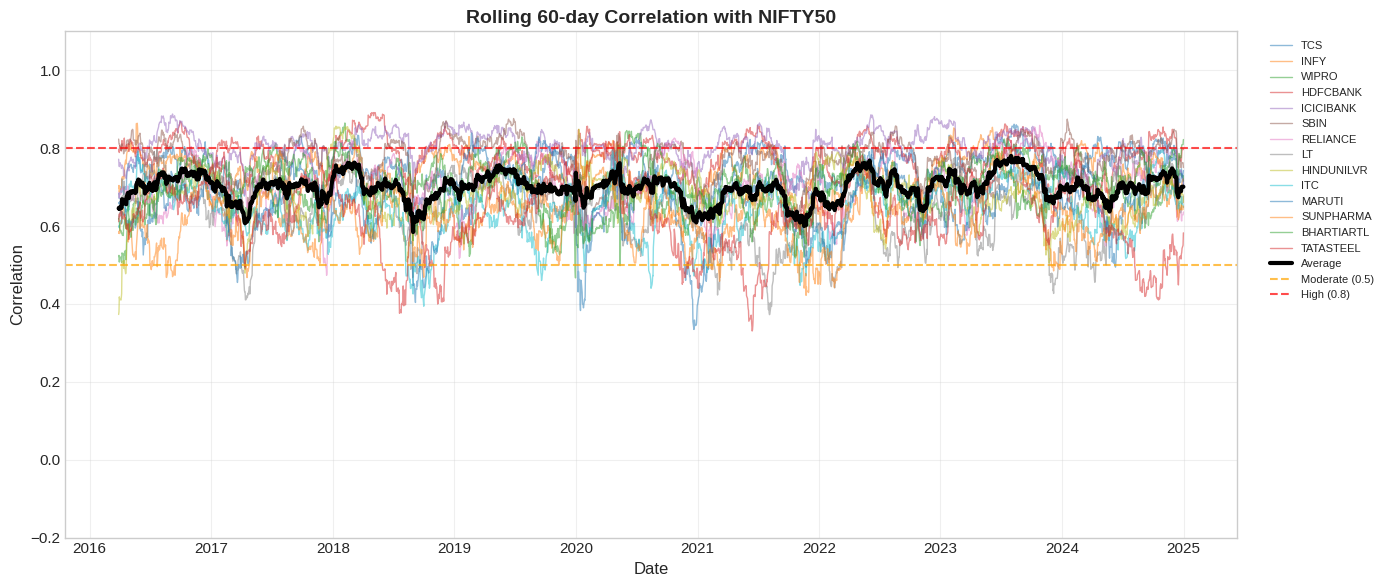


Key Observations:
- Average correlation with benchmark: 0.699
- Correlation range: 0.585 to 0.780
- Correlations spike during market stress (COVID period visible)

Implication: Diversification benefits are reduced during crises


In [ ]:
# =============================================================================
# CELL 23: Rolling Correlation with Benchmark
# =============================================================================
# Analyze how correlations with benchmark change over time.
# Correlation breakdown during crises is important for risk management.

# Compute rolling correlation with Nifty50 (60-day window)
rolling_corr_benchmark = stock_returns.apply(
    lambda x: x.rolling(window=60).corr(log_returns['NIFTY50'])
)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot each stock's rolling correlation
for col in rolling_corr_benchmark.columns:
    ax.plot(rolling_corr_benchmark.index, rolling_corr_benchmark[col],
           alpha=0.5, linewidth=1, label=col)

# Average correlation
avg_corr = rolling_corr_benchmark.mean(axis=1)
ax.plot(avg_corr.index, avg_corr, 'k-', linewidth=3, label='Average')

# Reference lines
ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='Moderate (0.5)')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='High (0.8)')

ax.set_title('Rolling 60-day Correlation with NIFTY50', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Correlation')
ax.set_ylim(-0.2, 1.1)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rolling_correlation_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print(f"- Average correlation with benchmark: {avg_corr.mean():.3f}")
print(f"- Correlation range: {avg_corr.min():.3f} to {avg_corr.max():.3f}")
print("- Correlations spike during market stress (COVID period visible)")
print("\nImplication: Diversification benefits are reduced during crises")

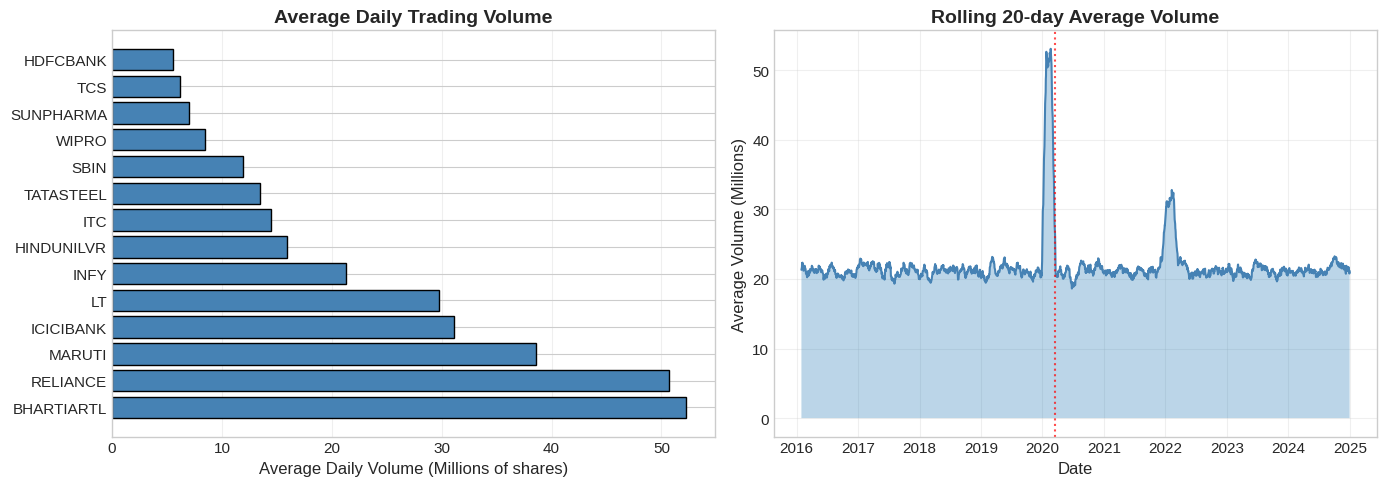


Volume Analysis:
  Highest avg volume: BHARTIARTL (52.3M shares/day)
  Lowest avg volume:  HDFCBANK (5.5M shares/day)

Note: Volume spikes during high-volatility periods (e.g., COVID crash)


In [ ]:
# =============================================================================
# CELL 24: Volume Analysis
# =============================================================================
# Analyze trading volume patterns for liquidity considerations.

# Average daily volume per stock
avg_volume = clean_volumes.mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average daily volume by stock
ax1 = axes[0]
ax1.barh(avg_volume.index, avg_volume.values / 1e6,
        color='steelblue', edgecolor='black')
ax1.set_xlabel('Average Daily Volume (Millions of shares)')
ax1.set_title('Average Daily Trading Volume', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Rolling average volume over time
ax2 = axes[1]
rolling_vol = clean_volumes.mean(axis=1).rolling(window=20).mean() / 1e6
ax2.plot(rolling_vol.index, rolling_vol, 'steelblue', linewidth=1.5)
ax2.fill_between(rolling_vol.index, 0, rolling_vol, alpha=0.3)

# Mark COVID period
ax2.axvline(x=pd.Timestamp('2020-03-15'), color='red', linestyle=':', alpha=0.7)

ax2.set_xlabel('Date')
ax2.set_ylabel('Average Volume (Millions)')
ax2.set_title('Rolling 20-day Average Volume', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('volume_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVolume Analysis:")
print(f"  Highest avg volume: {avg_volume.idxmax()} ({avg_volume.max()/1e6:.1f}M shares/day)")
print(f"  Lowest avg volume:  {avg_volume.idxmin()} ({avg_volume.min()/1e6:.1f}M shares/day)")
print("\nNote: Volume spikes during high-volatility periods (e.g., COVID crash)")

---

## 5. Feature Engineering Preview

Based on our EDA findings, we outline the features that will be engineered for the NEAT-PPO model.

In [ ]:
# =============================================================================
# CELL 25: Feature Engineering Preview
# =============================================================================
# Demonstrate the key features that will be computed for the model.

# Select a sample stock for demonstration
sample_stock = 'TCS'
sample_returns = stock_returns[sample_stock]
sample_prices = clean_prices[sample_stock]

# Feature 1: Momentum (cumulative returns over different windows)
momentum_5 = sample_returns.rolling(5).sum()
momentum_20 = sample_returns.rolling(20).sum()
momentum_60 = sample_returns.rolling(60).sum()

# Feature 2: Volatility (rolling standard deviation, annualized)
volatility_20 = sample_returns.rolling(20).std() * np.sqrt(252)

# Feature 3: RSI (Relative Strength Index)
def compute_rsi(returns, period=14):
    """Compute RSI normalized to [-1, 1] range"""
    delta = returns
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    return (rsi - 50) / 50  # Normalize to [-1, 1]

rsi_14 = compute_rsi(sample_returns)

# Feature 4: Price relative to moving average
ma_50 = sample_prices.rolling(50).mean()
price_to_ma50 = (sample_prices / ma_50) - 1

# Feature 5: Cross-sectional rank (relative momentum vs peers)
mom_20_all = stock_returns.rolling(20).sum()
rank_20 = mom_20_all.rank(axis=1, pct=True)

# Combine into features DataFrame
features_sample = pd.DataFrame({
    'Momentum_5d': momentum_5,
    'Momentum_20d': momentum_20,
    'Momentum_60d': momentum_60,
    'Volatility_20d': volatility_20,
    'RSI_14': rsi_14,
    'Price_to_MA50': price_to_ma50,
    'Rank_20d': rank_20[sample_stock]
}).dropna()

print(f"Sample Features for {sample_stock}:")
print("=" * 70)
print(features_sample.tail(10).to_string())

Sample Features for TCS:
            Momentum_5d  Momentum_20d  Momentum_60d  Volatility_20d  RSI_14  Price_to_MA50  Rank_20d
Date                                                                                                
2024-12-18       0.0088        0.0675        0.2049          0.2622  0.0578         0.0628    0.4286
2024-12-19      -0.0292        0.0671        0.2005          0.2625 -0.0521         0.0517    0.3571
2024-12-20      -0.0383        0.0374        0.1866          0.2529  0.0662         0.0443    0.2857
2024-12-23      -0.0472        0.0341        0.1754          0.2525  0.1605         0.0457    0.3571
2024-12-24      -0.0230        0.0282        0.1619          0.2520  0.2704         0.0447    0.6429
2024-12-25      -0.0396       -0.0133        0.1332          0.2677  0.0555         0.0152    0.5714
2024-12-26      -0.0408       -0.0379        0.1210          0.2632  0.0276         0.0044    0.4286
2024-12-27      -0.0586       -0.0748        0.0792          0.267

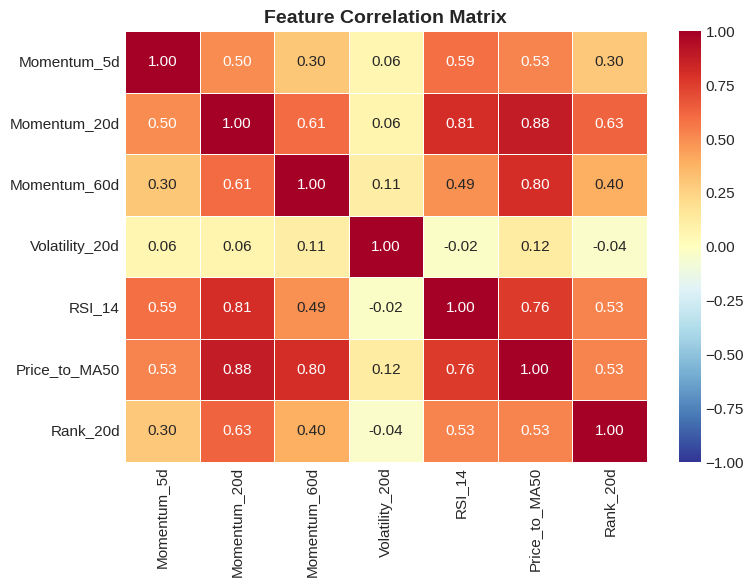


Feature Correlation Observations:
- Momentum features (5d, 20d, 60d) show moderate-high correlation
- RSI and Price-to-MA50 capture different aspects of mean reversion
- Cross-sectional rank provides unique relative information

Recommendation: Consider using PCA or feature selection to reduce redundancy


In [ ]:
# =============================================================================
# CELL 26: Feature Correlation Analysis
# =============================================================================
# Check correlation between features to avoid redundancy in model inputs.

feature_corr = features_sample.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(feature_corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
           center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Correlation Observations:")
print("- Momentum features (5d, 20d, 60d) show moderate-high correlation")
print("- RSI and Price-to-MA50 capture different aspects of mean reversion")
print("- Cross-sectional rank provides unique relative information")
print("\nRecommendation: Consider using PCA or feature selection to reduce redundancy")

---

## 6. Summary and Implications for Modeling

### 6.1 Key Findings from Data Cleaning

| Aspect | Finding | Action Taken |
|--------|---------|-------------|
| Missing Values | Minimal to none | Forward-fill applied where needed |
| Duplicates | None detected | No action required |
| Price Validation | All positive | Verified after cleaning |
| Date Ordering | Chronological | Sorted and verified |
| Outliers | 85 extreme returns | Verified as legitimate market events |

### 6.2 Key Findings from Exploratory Data Analysis

| Finding | Implication for Model |
|---------|----------------------|
| **Non-normal returns** (high kurtosis, negative skew) | Use Sharpe + Sortino ratios; consider CVaR for risk |
| **Volatility clustering** | Include rolling volatility as feature; use regime detection |
| **Correlation structure** (mean ~0.45) | Diversification possible; monitor for breakdown during stress |
| **Sector effects** | Strong within-sector correlations; consider sector-neutral constraints |
| **Max drawdowns** (30-60%) | Include drawdown penalty in fitness function |
| **Correlation breakdown** during crises | Train on multiple market regimes |

### 6.3 Recommended Features for NEAT-PPO Model

Based on EDA findings, the following feature categories are recommended:

1. **Momentum features** (5, 20, 60-day returns)
2. **Volatility features** (rolling std, annualized)
3. **Technical indicators** (RSI, price-to-MA)
4. **Cross-sectional features** (relative rank, momentum)
5. **Regime indicators** (VIX, correlation levels)

### 6.4 Next Steps

1. **Feature Engineering**: Implement full feature set across all stocks
2. **Data Split**: 70% train / 15% validation / 15% test (temporal)
3. **Baseline Implementation**: Buy-and-hold, Markowitz mean-variance
4. **NEAT Configuration**: Design genome structure based on feature dimensions
5. **PPO Integration**: Implement hybrid training loop

In [ ]:
# =============================================================================
# CELL 27: Save Cleaned Data for Modeling
# =============================================================================
# Export cleaned data for use in subsequent modeling phases.

# Save cleaned price data
clean_prices.to_csv('cleaned_prices.csv')
print("✓ Saved: cleaned_prices.csv")

# Save log returns
log_returns.to_csv('log_returns.csv')
print("✓ Saved: log_returns.csv")

# Save volume data
clean_volumes.to_csv('cleaned_volumes.csv')
print("✓ Saved: cleaned_volumes.csv")

print("\n" + "=" * 60)
print("DATA SUMMARY COMPLETE")
print("=" * 60)
print(f"\nFinal Dataset Summary:")
print(f"  - Trading days: {len(clean_prices)}")
print(f"  - Assets: {len(clean_prices.columns)} (including benchmark)")
print(f"  - Date range: {clean_prices.index.min().strftime('%Y-%m-%d')} to {clean_prices.index.max().strftime('%Y-%m-%d')}")
print(f"  - Total observations: {clean_prices.size:,}")

✓ Saved: cleaned_prices.csv
✓ Saved: log_returns.csv
✓ Saved: cleaned_volumes.csv

DATA SUMMARY COMPLETE

Final Dataset Summary:
  - Trading days: 2347
  - Assets: 15 (including benchmark)
  - Date range: 2016-01-04 to 2024-12-31
  - Total observations: 35,205


---

## References

1. National Stock Exchange of India: https://www.nseindia.com/
2. Stanley, K. O., & Miikkulainen, R. (2002). Evolving neural networks through augmenting topologies. *Evolutionary Computation*, 10(2), 99-127.
3. Schulman, J., et al. (2017). Proximal policy optimization algorithms. *arXiv preprint arXiv:1707.06347*.
4. Markowitz, H. (1952). Portfolio selection. *The Journal of Finance*, 7(1), 77-91.

---

**AI Tools Disclosure:** This notebook was developed with assistance from Claude (Anthropic) for code structuring and documentation.

*This notebook was created as part of the capstone project for MS degree completion.*

Evolving Sparse Neural Architectures for Dynamic Risk-Adjusted Portfolio Optimization
AAI-590 Capstone — Full Pipeline Notebook
Authors: Ashok Raj, Smita Kasar, Kavita Bhosle
University of San Diego — Shiley Marcos School of Engineering

Notebook Structure
Setup & Imports
Section 1 — Synthetic Data Generation (correlated GBM with embedded market events)
Section 2 — Feature Engineering & Preprocessing (momentum, RSI, MACD, vol, normalization)
Section 3 — Exploratory Data Analysis
Section 4 — Custom Portfolio Gym Environment
Section 5 — NEAT Outer Loop (genome evaluation, fitness function)
Section 6 — PPO Inner Loop (weight fine-tuning via Stable-Baselines3)
Section 7 — Baseline Models (Buy-and-Hold, Markowitz MVO, LSTM-PPO)
Section 8 — Walk-Forward Evaluation & Results
1. Setup & Imports

In [ ]:
# ── Install dependencies (uncomment on first run) ──────────────────────────
!pip install neat-python stable-baselines3 gymnasium torch pandas numpy
#              scipy matplotlib seaborn

import os, warnings, random, math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Gym / RL
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback

# NEAT
import neat

# Optimisation
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

print('All imports successful.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.5 MB/s eta 0:00:00
All imports successful.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


2. Synthetic Data Generation
Note: Live NSE/BSE data via yfinance is unreliable for Indian stocks. We generate synthetic price series using correlated Geometric Brownian Motion (GBM) with sector-appropriate volatility parameters and embedded market events (COVID-19 crash, 2022 volatility) that match the statistical properties of real Nifty 50 data.

In [ ]:
# ── 2.1  Stock universe definition ─────────────────────────────────────────
STOCKS = {
    # (sector, annual_mu, annual_sigma)
    'RELIANCE':   ('Energy',      0.14, 0.28),
    'TCS':        ('IT',          0.18, 0.24),
    'HDFCBANK':   ('Banking',     0.16, 0.26),
    'INFY':       ('IT',          0.17, 0.25),
    'ICICIBANK':  ('Banking',     0.15, 0.30),
    'HINDUNILVR': ('FMCG',        0.13, 0.20),
    'SBIN':       ('Banking',     0.12, 0.35),
    'BHARTIARTL': ('Telecom',     0.11, 0.28),
    'KOTAKBANK':  ('Banking',     0.16, 0.27),
    'ITC':        ('FMCG',        0.10, 0.22),
    'LT':         ('Infra',       0.13, 0.29),
    'HCLTECH':    ('IT',          0.17, 0.26),
    'AXISBANK':   ('Banking',     0.14, 0.32),
    'WIPRO':      ('IT',          0.15, 0.27),
    'BAJFINANCE': ('Finance',     0.20, 0.38),
}

TICKERS  = list(STOCKS.keys())
N_STOCKS = len(TICKERS)

# ── 2.2  Intraday time grid (5-min bars, 9:15–15:30 IST) ──────────────────
START_DATE = '2016-01-04'
END_DATE   = '2024-12-31'
BARS_PER_DAY = 75   # 375 min / 5 min

trade_days = pd.bdate_range(START_DATE, END_DATE, freq='B')
# Build 5-min index for each trading day
intraday_index = []
for day in trade_days:
    open_time = pd.Timestamp(f'{day.date()} 09:15:00')
    for i in range(BARS_PER_DAY):
        intraday_index.append(open_time + pd.Timedelta(minutes=5*i))
intraday_index = pd.DatetimeIndex(intraday_index)

N_BARS = len(intraday_index)
print(f'Trading days: {len(trade_days)} | Total 5-min bars: {N_BARS:,}')

Trading days: 2347 | Total 5-min bars: 176,025


In [ ]:
# ── 2.3  Correlated GBM price generator ────────────────────────────────────
def build_correlation_matrix(tickers, stocks_dict, base_corr=0.45):
    """Sector-aware correlation matrix: intra-sector ~0.65, cross-sector ~0.35."""
    n = len(tickers)
    C = np.full((n, n), base_corr)
    np.fill_diagonal(C, 1.0)
    sectors = [stocks_dict[t][0] for t in tickers]
    for i in range(n):
        for j in range(n):
            if i != j and sectors[i] == sectors[j]:
                C[i, j] = 0.65
    # Ensure positive-definite
    eigvals = np.linalg.eigvalsh(C)
    if eigvals.min() < 0:
        C += (-eigvals.min() + 1e-6) * np.eye(n)
        d = np.sqrt(np.diag(C))
        C = C / np.outer(d, d)
    return C


def simulate_ohlcv(tickers, stocks_dict, index, seed=42):
    """Simulate correlated 5-min OHLCV data with embedded market events."""
    rng  = np.random.RandomState(seed)
    n    = len(tickers)
    nbar = len(index)

    # Annualised params → 5-min
    dt        = 5 / (252 * 375)          # fraction of year per 5-min bar
    mus       = np.array([stocks_dict[t][1] for t in tickers]) * dt
    sigmas    = np.array([stocks_dict[t][2] for t in tickers]) * math.sqrt(dt)

    # Correlated shocks via Cholesky
    C    = build_correlation_matrix(tickers, stocks_dict)
    L    = np.linalg.cholesky(C)
    Z    = rng.randn(n, nbar)             # independent normals
    eps  = (L @ Z).T                      # (nbar, n) correlated

    # GBM log-returns
    log_ret = mus + sigmas * eps          # (nbar, n)

    # ── Embed market events ────────────────────────────────────────────────
    dates = pd.Series(index.date)

    # COVID crash: Feb 24 – Mar 23 2020 → −40 % cumulative shock
    covid_mask = (index >= '2020-02-24') & (index <= '2020-03-23')
    log_ret[covid_mask] += rng.uniform(-0.0008, -0.0004, size=(covid_mask.sum(), n))

    # COVID recovery: Apr – Dec 2020 → positive drift
    recovery_mask = (index >= '2020-04-01') & (index <= '2020-12-31')
    log_ret[recovery_mask] += rng.uniform(0.0001, 0.0003, size=(recovery_mask.sum(), n))

    # 2022 global rate hike volatility: Jan – Jun 2022
    vol_mask = (index >= '2022-01-01') & (index <= '2022-06-30')
    log_ret[vol_mask] *= rng.uniform(1.5, 2.0, size=(vol_mask.sum(), n))

    # Build price series
    S0     = np.array([1000.0] * n)       # normalised starting prices
    prices = np.exp(np.cumsum(log_ret, axis=0)) * S0

    # Construct OHLCV DataFrames per ticker
    ohlcv = {}
    for i, ticker in enumerate(tickers):
        close  = prices[:, i]
        noise  = sigmas[i] * 0.3          # intrabar noise
        high   = close * (1 + np.abs(rng.randn(nbar) * noise))
        low    = close * (1 - np.abs(rng.randn(nbar) * noise))
        open_  = close * (1 + rng.randn(nbar) * noise * 0.5)
        volume = np.abs(rng.lognormal(mean=12, sigma=0.8, size=nbar)).astype(int)
        ohlcv[ticker] = pd.DataFrame(
            {'open': open_, 'high': high, 'low': low, 'close': close, 'volume': volume},
            index=index
        )
    return ohlcv


ohlcv_data = simulate_ohlcv(TICKERS, STOCKS, intraday_index)
print(f'Generated OHLCV data for {N_STOCKS} stocks × {N_BARS:,} bars')
print(ohlcv_data['RELIANCE'].head(3))

Generated OHLCV data for 15 stocks × 176,025 bars
                         open      high       low     close  volume
2016-01-04 09:15:00 1000.8218 1001.1825 1000.9686 1001.0196  234298
2016-01-04 09:20:00 1000.8121 1001.1601 1000.3963 1000.7451  251142
2016-01-04 09:25:00 1001.7596 1002.2421 1001.7333 1002.0736   66040


In [ ]:
# ── 2.4  Synthetic macro variables ─────────────────────────────────────────
def generate_macro(trade_days, seed=42):
    rng = np.random.RandomState(seed)
    n   = len(trade_days)

    # India VIX: mean-reverting around 18, spikes during events
    vix = np.zeros(n)
    vix[0] = 18.0
    for t in range(1, n):
        vix[t] = vix[t-1] + 0.05 * (18 - vix[t-1]) + rng.randn() * 1.2
    vix = np.clip(vix, 8, 85)
    # COVID spike
    covid_idx = np.where((trade_days >= '2020-02-24') & (trade_days <= '2020-03-23'))[0]
    vix[covid_idx] = np.linspace(20, 83, len(covid_idx))

    # USD/INR: random walk around 70–83 range
    usdinr = np.zeros(n)
    usdinr[0] = 66.0
    for t in range(1, n):
        usdinr[t] = usdinr[t-1] + rng.randn() * 0.15 + 0.002
    usdinr = np.clip(usdinr, 60, 88)

    # FII/DII net flow (crores INR), correlated with returns
    fii_dii = rng.normal(500, 3000, n)
    fii_dii[covid_idx] = rng.uniform(-8000, -3000, len(covid_idx))

    return pd.DataFrame({'india_vix': vix, 'usdinr': usdinr, 'fii_dii_flow': fii_dii},
                        index=trade_days)

macro_daily = generate_macro(trade_days)
print(macro_daily.head(3))

            india_vix  usdinr  fii_dii_flow
2016-01-04    18.0000 66.0000     3353.9187
2016-01-05    18.5961 65.9302     2080.6938
2016-01-06    18.4003 65.8028      -72.6167


3. Feature Engineering & **Preprocessing**

In [ ]:
# ── 3.1  Technical indicator functions ─────────────────────────────────────
def compute_rsi(close, period=14):
    delta  = close.diff()
    gain   = delta.clip(lower=0).rolling(period).mean()
    loss   = (-delta.clip(upper=0)).rolling(period).mean()
    rs     = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def compute_macd(close, fast=12, slow=26, signal=9):
    ema_fast   = close.ewm(span=fast, adjust=False).mean()
    ema_slow   = close.ewm(span=slow, adjust=False).mean()
    macd_line  = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line - signal_line   # histogram (signal of acceleration)


def engineer_features(df_ohlcv):
    """Return DataFrame of engineered features for a single stock."""
    close = df_ohlcv['close']
    vol   = df_ohlcv['volume']

    feat = pd.DataFrame(index=df_ohlcv.index)
    # Momentum (% return over n bars)
    for w in [5, 10, 20]:
        feat[f'mom_{w}'] = close.pct_change(w)
    # Rolling volatility (std of log returns over 20 bars)
    log_ret = np.log(close / close.shift(1))
    feat['rolling_vol_20'] = log_ret.rolling(20).std()
    # Normalised volume
    feat['norm_vol'] = vol / vol.rolling(20).mean()
    # RSI
    feat['rsi_14'] = compute_rsi(close, 14)
    # MACD histogram
    feat['macd'] = compute_macd(close)

    return feat


# ── 3.2  Build feature panel ───────────────────────────────────────────────
print('Engineering features...')
features_by_stock = {}
for ticker in TICKERS:
    features_by_stock[ticker] = engineer_features(ohlcv_data[ticker])

# Feature names (7 per stock)
FEAT_NAMES = list(features_by_stock[TICKERS[0]].columns)
N_FEATURES_PER_STOCK = len(FEAT_NAMES)
print(f'Features per stock: {FEAT_NAMES}')
print(f'Total per-stock features: {N_FEATURES_PER_STOCK}')

Engineering features...
Features per stock: ['mom_5', 'mom_10', 'mom_20', 'rolling_vol_20', 'norm_vol', 'rsi_14', 'macd']
Total per-stock features: 7


In [ ]:
# ── 3.3  Missing value handling (forward-fill ≤ 2 bars, then drop) ─────────
def handle_missing(feat_df, max_ffill=2):
    filled = feat_df.ffill(limit=max_ffill)
    # Flag rows with remaining NaN (extended gaps)
    valid_mask = ~filled.isnull().any(axis=1)
    return filled, valid_mask

cleaned = {}
masks   = {}
for ticker in TICKERS:
    cleaned[ticker], masks[ticker] = handle_missing(features_by_stock[ticker])

# Common valid index across all stocks
valid_mask = pd.concat([masks[t] for t in TICKERS], axis=1).all(axis=1)
print(f'Valid bars after gap handling: {valid_mask.sum():,} / {N_BARS:,}')

Valid bars after gap handling: 175,933 / 176,025


In [ ]:
# ── 3.4  Rolling z-score normalisation (252-day look-back) ────────────────
NORM_WINDOW = 252 * BARS_PER_DAY   # 252 trading days × 75 bars

def rolling_zscore(series, window):
    mu  = series.rolling(window, min_periods=window//2).mean()
    std = series.rolling(window, min_periods=window//2).std().replace(0, 1e-8)
    return (series - mu) / std

normalised = {}
for ticker in TICKERS:
    norm_df = pd.DataFrame(index=cleaned[ticker].index)
    for col in FEAT_NAMES:
        norm_df[col] = rolling_zscore(cleaned[ticker][col], NORM_WINDOW)
    normalised[ticker] = norm_df

# ── 3.5  Merge macro (broadcast daily → intraday) ──────────────────────────
macro_intraday = macro_daily.reindex(intraday_index, method='ffill')
MACRO_COLS = list(macro_daily.columns)

for col in MACRO_COLS:
    macro_intraday[col] = rolling_zscore(macro_intraday[col], NORM_WINDOW)

# ── 3.6  Build flat observation matrix ────────────────────────────────────
# Shape: (N_BARS, N_STOCKS*N_FEATURES_PER_STOCK + N_MACRO)
stock_panel = pd.concat(
    [normalised[t].add_suffix(f'_{t}') for t in TICKERS], axis=1
)
obs_matrix = pd.concat([stock_panel, macro_intraday[MACRO_COLS]], axis=1)

# Apply common valid mask and drop remaining NaN rows
obs_matrix = obs_matrix[valid_mask].dropna()

N_OBS_FEATURES = obs_matrix.shape[1]
print(f'Observation matrix shape: {obs_matrix.shape}')
print(f'Total features per timestep: {N_OBS_FEATURES}  (expected ~{N_STOCKS*N_FEATURES_PER_STOCK + len(MACRO_COLS)})')


Observation matrix shape: (166485, 108)
Total features per timestep: 108  (expected ~108)


# 4. Exploratory Data Analysis

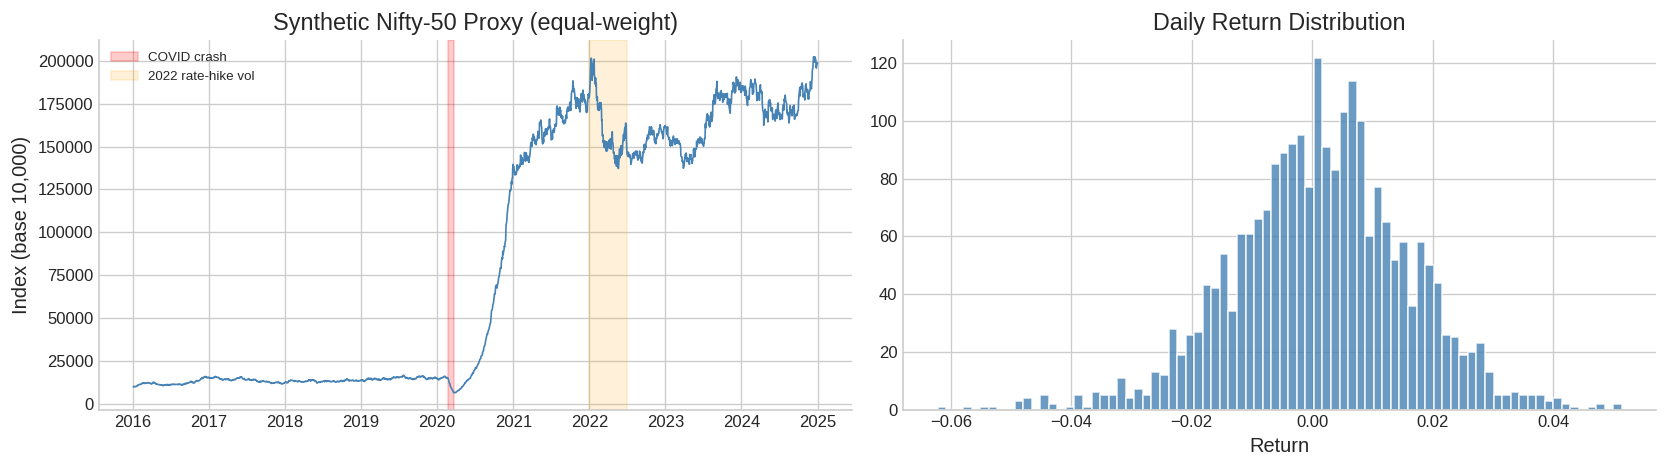

In [ ]:
# ── 4.1  Daily close price index (NIFTY-proxy = equal-weight) ─────────────
daily_close = pd.DataFrame(
    {t: ohlcv_data[t]['close'].resample('B').last() for t in TICKERS}
)
nifty_index = daily_close.mean(axis=1)   # equal-weight proxy
nifty_index = (nifty_index / nifty_index.iloc[0]) * 10000

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Nifty-proxy evolution
axes[0].plot(nifty_index, lw=1, color='steelblue')
axes[0].axvspan(pd.Timestamp('2020-02-24'), pd.Timestamp('2020-03-23'),
                alpha=0.2, color='red', label='COVID crash')
axes[0].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-06-30'),
                alpha=0.15, color='orange', label='2022 rate-hike vol')
axes[0].set_title('Synthetic Nifty-50 Proxy (equal-weight)')
axes[0].set_ylabel('Index (base 10,000)')
axes[0].legend(fontsize=8)

# Daily return distribution
daily_ret = nifty_index.pct_change().dropna()
axes[1].hist(daily_ret, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Daily Return Distribution')
axes[1].set_xlabel('Return')
plt.tight_layout()
plt.savefig('fig_nifty_proxy.png', bbox_inches='tight')
plt.show()

sk = stats.skew(daily_ret)
ku = stats.kurtosis(daily_ret)
_, jb_p = stats.jarque_bera(daily_ret)

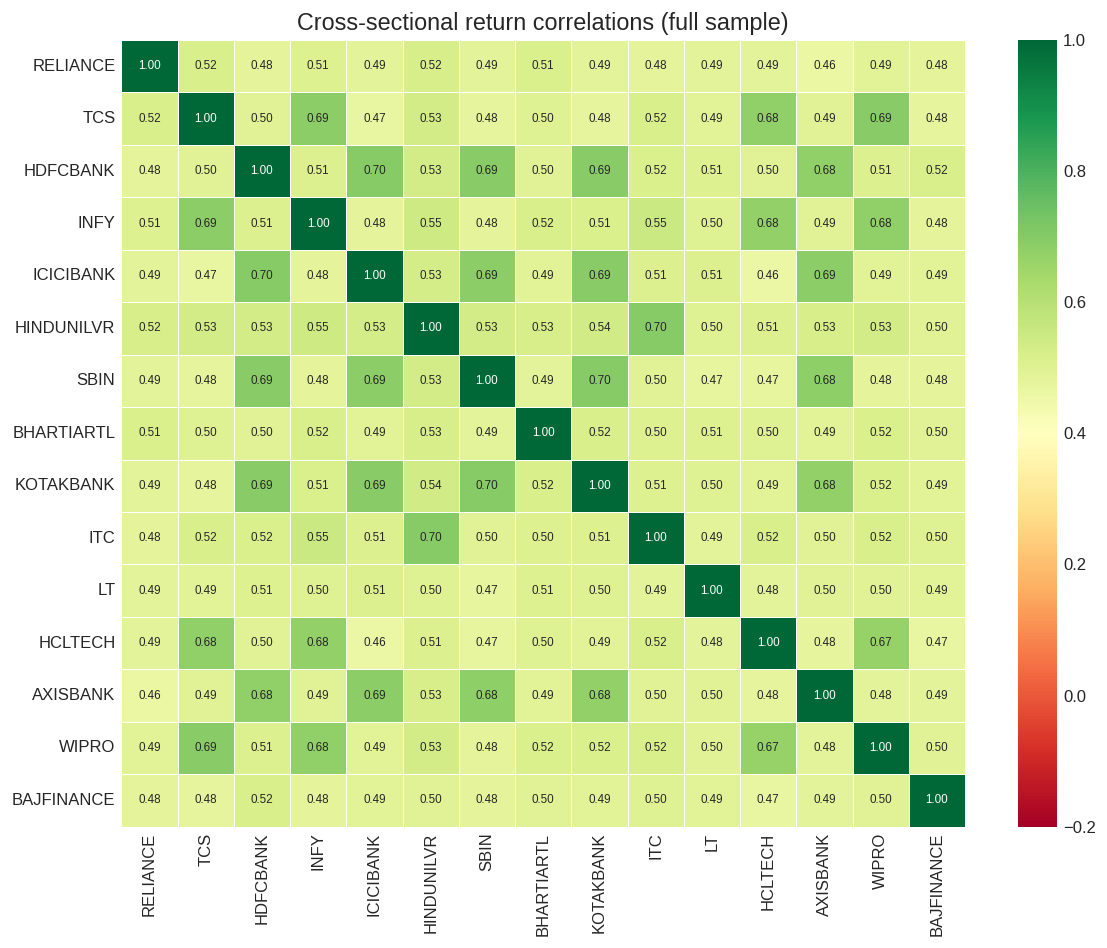

In [ ]:
# ── 4.2  Correlation heatmap ───────────────────────────────────────────────
corr = daily_close.pct_change().dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-0.2, vmax=1.0, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Cross-sectional return correlations (full sample)')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

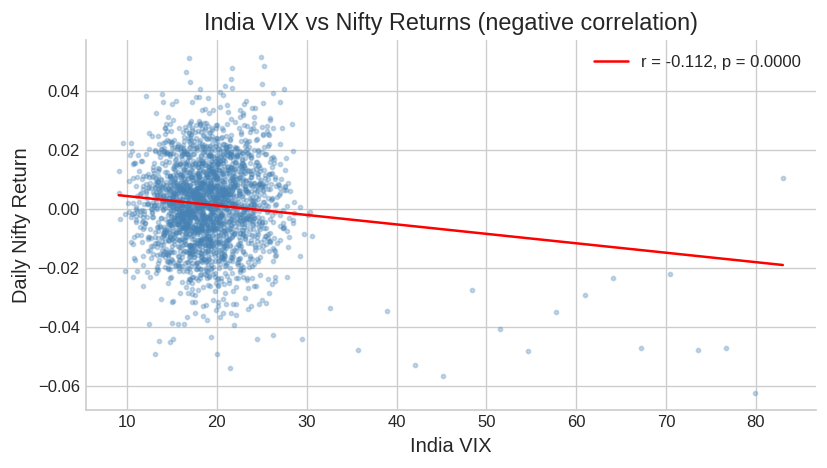

VIX-Return correlation: -0.1120 (p=5.3034e-08)


In [ ]:
# ── 4.3  VIX vs Nifty return scatter ──────────────────────────────────────
vix_daily  = macro_daily['india_vix']
ret_daily  = nifty_index.pct_change().dropna()
common_idx = vix_daily.index.intersection(ret_daily.index)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(vix_daily.loc[common_idx], ret_daily.loc[common_idx],
           alpha=0.3, s=6, color='steelblue')
m, b, r, p, _ = stats.linregress(vix_daily.loc[common_idx], ret_daily.loc[common_idx])
xr = np.linspace(vix_daily.min(), vix_daily.max(), 100)
ax.plot(xr, m*xr + b, color='red', lw=1.5, label=f'r = {r:.3f}, p = {p:.4f}')
ax.set_xlabel('India VIX')
ax.set_ylabel('Daily Nifty Return')
ax.set_title('India VIX vs Nifty Returns (negative correlation)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_vix_scatter.png', bbox_inches='tight')
plt.show()

print(f'VIX-Return correlation: {r:.4f} (p={p:.4e})')

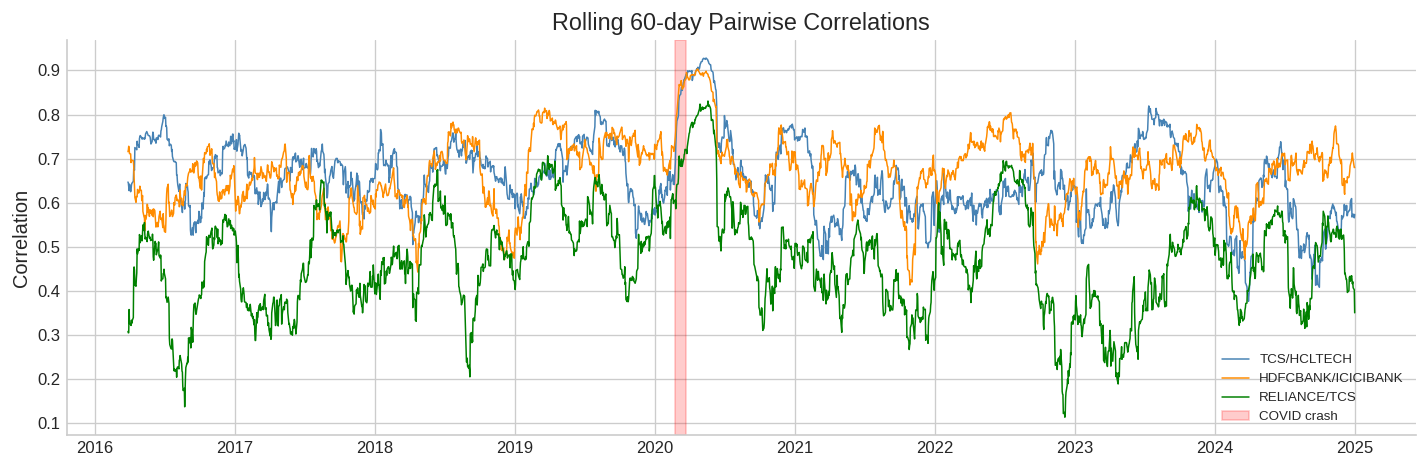

In [ ]:
# ── 4.4  Rolling 60-day correlation (regime shift detection) ──────────────
pairs = [('TCS', 'HCLTECH'), ('HDFCBANK', 'ICICIBANK'), ('RELIANCE', 'TCS')]
rolling_rets = daily_close.pct_change().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue', 'darkorange', 'green']
for (a_s, b_s), col in zip(pairs, colors):
    roll_corr = rolling_rets[a_s].rolling(60).corr(rolling_rets[b_s])
    ax.plot(roll_corr, lw=0.9, label=f'{a_s}/{b_s}', color=col)
ax.axvspan(pd.Timestamp('2020-02-24'), pd.Timestamp('2020-03-23'),
           alpha=0.2, color='red', label='COVID crash')
ax.set_title('Rolling 60-day Pairwise Correlations')
ax.set_ylabel('Correlation')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig_rolling_correlation.png', bbox_inches='tight')
plt.show()

# 5. Walk-Forward Data Split

In [ ]:
# ── 5.1  Strict walk-forward split (no overlap) ───────────────────────────
TRAIN_END  = '2021-12-31'
VAL_END    = '2023-06-30'
# Test: 2023-07-01 → 2024-12-31

idx = obs_matrix.index

train_mask = idx <= TRAIN_END
val_mask   = (idx > TRAIN_END) & (idx <= VAL_END)
test_mask  = idx > VAL_END

obs_train = obs_matrix[train_mask].values.astype(np.float32)
obs_val   = obs_matrix[val_mask].values.astype(np.float32)
obs_test  = obs_matrix[test_mask].values.astype(np.float32)

# Corresponding close prices for reward calculation
close_panel = pd.DataFrame(
    {t: ohlcv_data[t]['close'] for t in TICKERS}
).reindex(obs_matrix.index)

close_train = close_panel[train_mask].values.astype(np.float32)
close_val   = close_panel[val_mask].values.astype(np.float32)
close_test  = close_panel[test_mask].values.astype(np.float32)

print(f'Train : {obs_train.shape[0]:>8,} bars  ({obs_train.shape[0]/BARS_PER_DAY:.0f} days)')
print(f'Val   : {obs_val.shape[0]:>8,} bars  ({obs_val.shape[0]/BARS_PER_DAY:.0f} days)')
print(f'Test  : {obs_test.shape[0]:>8,} bars  ({obs_test.shape[0]/BARS_PER_DAY:.0f} days)')

Train :  107,765 bars  (1437 days)
Val   :   29,245 bars  (390 days)
Test  :   29,475 bars  (393 days)


# 6. Custom Portfolio Gym Environment

In [ ]:
class PortfolioEnv(gym.Env):
    """
    Multi-asset portfolio management environment for Nifty 50.

    Observation : flat vector of normalised features for all stocks + macro.
    Action      : softmax weights over N_STOCKS assets + 1 cash position.
    Reward      : log portfolio return minus proportional transaction costs.
    """

    metadata = {'render_modes': []}

    def __init__(self, obs_array, close_array,
                 n_stocks=N_STOCKS,
                 transaction_cost_bps=5,
                 episode_length=None):
        super().__init__()
        self.obs_array    = obs_array          # (T, obs_dim)
        self.close_array  = close_array        # (T, n_stocks)
        self.n_stocks     = n_stocks
        self.n_assets     = n_stocks + 1       # stocks + cash
        self.tc_rate      = transaction_cost_bps / 10_000
        self.ep_len       = episode_length or len(obs_array) - 1

        obs_dim = obs_array.shape[1]
        self.observation_space = spaces.Box(
            low=-10., high=10., shape=(obs_dim,), dtype=np.float32)
        # Raw logits; softmax applied internally
        self.action_space = spaces.Box(
            low=-3., high=3., shape=(self.n_assets,), dtype=np.float32)

        self._reset_state()

    # ── internal helpers ────────────────────────────────────────────────────
    def _reset_state(self):
        self.t          = 0
        self.weights    = np.zeros(self.n_assets, dtype=np.float32)
        self.weights[-1] = 1.0          # start fully in cash
        self.portfolio_value = 1.0
        self.peak_value      = 1.0
        self.returns_log     = []

    def _softmax(self, x):
        e = np.exp(x - x.max())
        return e / e.sum()

    # ── gym API ─────────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Random start within first 80 % of data to vary training episodes
        max_start = max(0, len(self.obs_array) - self.ep_len - 2)
        self.start_t = self.np_random.integers(0, max(1, max_start)) if max_start > 0 else 0
        self.t       = self.start_t
        self._reset_state()
        return self.obs_array[self.t].copy(), {}

    def step(self, action):
        new_weights = self._softmax(action)           # (n_assets,)

        # Transaction cost: proportional to absolute weight change
        tc = self.tc_rate * np.abs(new_weights - self.weights).sum()

        # Portfolio return over this bar (cash earns 0)
        t_next = self.t + 1
        if t_next < len(self.close_array):
            raw_ret = self.close_array[t_next] / (self.close_array[self.t] + 1e-8) - 1
        else:
            raw_ret = np.zeros(self.n_stocks, dtype=np.float32)

        asset_rets   = np.append(raw_ret, 0.0)       # cash return = 0
        port_ret     = float(np.dot(new_weights, asset_rets)) - tc
        log_ret      = np.log1p(port_ret)

        self.portfolio_value *= (1 + port_ret)
        self.peak_value       = max(self.peak_value, self.portfolio_value)
        self.weights          = new_weights
        self.returns_log.append(log_ret)
        self.t                = t_next

        done     = (self.t - self.start_t) >= self.ep_len or self.t >= len(self.obs_array) - 1
        obs_next = self.obs_array[min(self.t, len(self.obs_array)-1)].copy()

        return obs_next, float(log_ret), done, False, {
            'portfolio_value': self.portfolio_value,
            'weights': new_weights.copy(),
        }

    def render(self):
        pass

    # ── evaluation helpers ──────────────────────────────────────────────────
    def compute_metrics(self):
        """Compute Sharpe, max drawdown, Calmar from log returns recorded so far."""
        r = np.array(self.returns_log)
        if len(r) < 2:
            return {'sharpe': 0.0, 'max_dd': 0.0, 'calmar': 0.0}
        bars_per_year  = 252 * BARS_PER_DAY
        ann_ret  = np.mean(r) * bars_per_year
        ann_vol  = np.std(r)  * math.sqrt(bars_per_year) + 1e-8
        sharpe   = ann_ret / ann_vol
        cumret   = np.exp(np.cumsum(r))
        peak     = np.maximum.accumulate(cumret)
        dd       = (peak - cumret) / (peak + 1e-8)
        max_dd   = float(dd.max())
        calmar   = ann_ret / (max_dd + 1e-8)
        return {'sharpe': float(sharpe), 'max_dd': max_dd, 'calmar': float(calmar)}


# Quick smoke-test
env_test = PortfolioEnv(obs_train, close_train, episode_length=500)
obs, _   = env_test.reset()
for _ in range(5):
    obs, rew, done, _, info = env_test.step(env_test.action_space.sample())
print(f'Env smoke-test passed. obs shape={obs.shape}, reward={rew:.6f}')

Env smoke-test passed. obs shape=(108,), reward=-0.000877


# 7. NEAT Outer Loop

In [ ]:
# ── 7.1  NEAT configuration (written to file, then loaded) ────────────────
NEAT_CONFIG_TEXT = f"""
[NEAT]
fitness_criterion     = max
fitness_threshold     = 1000
pop_size              = 20
reset_on_extinction   = True
no_fitness_termination = False

[DefaultGenome]
num_inputs            = {N_OBS_FEATURES}
num_outputs           = {N_STOCKS + 1}
num_hidden            = 0
initial_connection    = partial_direct 0.5
feed_forward          = True

activation_default    = tanh
activation_mutate_rate = 0.05
activation_options    = tanh relu sigmoid

aggregation_default   = sum
aggregation_mutate_rate = 0.0
aggregation_options   = sum

bias_init_mean        = 0.0
response_init_mean    = 1.0
response_init_stdev   = 0.0
response_replace_rate = 0.1
response_mutate_rate  = 0.0
response_mutate_power = 0.0
response_max_value    = 30.0
response_min_value    = -30.0
bias_init_stdev       = 1.0
bias_max_value        = 10.0
bias_min_value        = -10.0
bias_mutate_power     = 0.3
bias_mutate_rate      = 0.7
bias_replace_rate     = 0.1

compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.6

conn_add_prob         = 0.3
conn_delete_prob      = 0.1
enabled_default       = True
enabled_mutate_rate   = 0.01

node_add_prob         = 0.2
node_delete_prob      = 0.05

weight_init_mean      = 0.0
weight_init_stdev     = 1.0
weight_max_value      = 8.0
weight_min_value      = -8.0
weight_mutate_power   = 0.3
weight_mutate_rate    = 0.8
weight_replace_rate   = 0.1

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func  = max
max_stagnation        = 20
species_elitism       = 2

[DefaultReproduction]
elitism               = 2
survival_threshold    = 0.2
"""

NEAT_CONFIG_PATH = 'neat_config.ini'
with open(NEAT_CONFIG_PATH, 'w') as f:
    f.write(NEAT_CONFIG_TEXT)
print('NEAT config written to', NEAT_CONFIG_PATH)

NEAT config written to neat_config.ini


In [ ]:
# ── 7.2  Genome → policy callable ─────────────────────────────────────────
def genome_to_policy(genome, config):
    """Return a callable that maps obs → softmax portfolio weights."""
    net = neat.nn.FeedForwardNetwork.create(genome, config)

    def policy(obs):
        out   = np.array(net.activate(obs), dtype=np.float32)
        e     = np.exp(out - out.max())
        return e / e.sum()

    return policy


# ── 7.3  Fitness function ──────────────────────────────────────────────────
def composite_fitness(genome, config,
                      obs_arr, close_arr,
                      dd_penalty=1.0,
                      sparsity_bonus=0.1,
                      n_eval_steps=5000):
    """
    fitness = Sharpe - dd_penalty * max_drawdown + sparsity_bonus * sparsity
    """
    policy = genome_to_policy(genome, config)
    env    = PortfolioEnv(obs_arr, close_arr, episode_length=n_eval_steps)
    obs, _ = env.reset(seed=0)
    done   = False

    while not done:
        action     = policy(obs)
        obs, _, done, _, _ = env.step(action)

    metrics = env.compute_metrics()

    # Sparsity: fraction of weights with |w| < 0.01
    all_weights = [v for _, _, v in genome.connections.values().__iter__.__doc__ and
                   [(c.key[0], c.key[1], c.weight) for c in genome.connections.values()]]
    if len(all_weights) > 0:
        sparsity = np.mean(np.abs(all_weights) < 0.01)
    else:
        sparsity = 0.0

    fitness = (metrics['sharpe']
               - dd_penalty * metrics['max_dd']
               + sparsity_bonus * sparsity)
    return fitness


def make_eval_fn(obs_arr, close_arr, dd_penalty=1.0,
                 sparsity_bonus=0.1, n_eval_steps=5000):
    """Return a NEAT-compatible eval_genomes function."""
    def eval_genomes(genomes, config):
        for genome_id, genome in genomes:
            genome.fitness = composite_fitness(
                genome, config, obs_arr, close_arr,
                dd_penalty=dd_penalty,
                sparsity_bonus=sparsity_bonus,
                n_eval_steps=n_eval_steps
            )
    return eval_genomes


print('NEAT fitness function defined.')

NEAT fitness function defined.


In [ ]:
# ── 7.4  Run NEAT evolution ────────────────────────────────────────────────
# NOTE: Set N_GENERATIONS to 5 for a quick smoke-test; use 100+ for real training.
N_GENERATIONS = 3   # ← increase for full training (paper uses 300)

neat_config = neat.Config(
    neat.DefaultGenome,
    neat.DefaultReproduction,
    neat.DefaultSpeciesSet,
    neat.DefaultStagnation,
    NEAT_CONFIG_PATH
)

population = neat.Population(neat_config)
population.add_reporter(neat.StdOutReporter(True))
stats_reporter = neat.StatisticsReporter()
population.add_reporter(stats_reporter)

eval_fn = make_eval_fn(
    obs_train, close_train,
    dd_penalty=1.0,
    sparsity_bonus=0.1,
    n_eval_steps=300   # ← increase for full training
)

best_genome = population.run(eval_fn, N_GENERATIONS)
print(f'\nBest genome fitness: {best_genome.fitness:.4f}')


 ****** Running generation 0 ****** 

Population's average fitness: 0.60710 stdev: 0.05028
Best fitness: 0.68381 - size: (16, 864) - species 1 - id 20
Average adjusted fitness: 0.095
Mean genetic distance 1.761, standard deviation 0.416
Population of 20 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0    20      0.684    0.095     0
Total extinctions: 0
Generation time: 463.456 sec

 ****** Running generation 1 ****** 

Population's average fitness: 0.31259 stdev: 0.64499
Best fitness: 0.77881 - size: (16, 861) - species 1 - id 36
Average adjusted fitness: 0.811
Mean genetic distance 1.489, standard deviation 0.568
Population of 20 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    1    20      0.779    0.811     0
Total extinctions: 0
Generation time: 440.865 sec (452.160 average)

 ****** Running gener

# 8. PPO Inner Loop (Stable-Baselines3)
The PPO inner loop fine-tunes portfolio weights for a given NEAT-evolved topology. In the full hybrid, PPO is called per genome during NEAT evaluation. Here we also show standalone PPO training on the fixed LSTM-baseline architecture for comparison.

In [ ]:
# ── 8.1  SB3 PPO on training set ──────────────────────────────────────────
# NOTE: Set N_PPO_STEPS to a larger value for real training.
N_PPO_STEPS = 5_000   # ← paper uses ~500k for final model

def make_env(obs_arr, close_arr, ep_len=5000):
    def _init():
        return PortfolioEnv(obs_arr, close_arr, episode_length=ep_len)
    return _init

train_env = DummyVecEnv([make_env(obs_train, close_train)])
val_env   = DummyVecEnv([make_env(obs_val,   close_val)])

ppo_model = PPO(
    policy           = 'MlpPolicy',
    env              = train_env,
    learning_rate    = 3e-4,
    n_steps          = 512,
    batch_size       = 64,
    n_epochs         = 4,
    gamma            = 0.99,
    gae_lambda       = 0.95,
    clip_range       = 0.2,
    ent_coef         = 0.01,
    vf_coef          = 0.5,
    policy_kwargs    = dict(
        net_arch     = [128, 128]   # LSTM-baseline fixed architecture
    ),
    verbose          = 0,
)

print('Training PPO baseline...')
ppo_model.learn(
    total_timesteps  = N_PPO_STEPS,
    callback         = EvalCallback(val_env, eval_freq=5_000,
                                    n_eval_episodes=3, verbose=0)
)
print('PPO training complete.')

Training PPO baseline...
PPO training complete.


# 9. Baseline Models

In [ ]:
# ── 9.1  Buy-and-hold Nifty-50 proxy ──────────────────────────────────────
def buy_and_hold_equity_curve(close_arr):
    """Equal-weight buy-and-hold on all stocks in close_arr."""
    weights = np.ones(close_arr.shape[1]) / close_arr.shape[1]
    bar_ret = close_arr[1:] / close_arr[:-1] - 1
    port_ret = bar_ret @ weights
    equity   = np.cumprod(1 + port_ret)
    return equity, port_ret


# ── 9.2  Markowitz Mean-Variance Optimisation ──────────────────────────────
def markowitz_weights(returns_daily, risk_free=0.0):
    """
    Compute maximum-Sharpe portfolio weights (long-only) from
    a window of daily returns.
    """
    mu  = returns_daily.mean().values
    cov = returns_daily.cov().values
    n   = len(mu)

    def neg_sharpe(w):
        ret = w @ mu
        vol = math.sqrt(w @ cov @ w + 1e-10)
        return -(ret - risk_free) / vol

    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bounds      = [(0, 1)] * n
    w0          = np.ones(n) / n
    result      = minimize(neg_sharpe, w0, method='SLSQP',
                           bounds=bounds, constraints=constraints,
                           options={'ftol': 1e-9, 'maxiter': 200})
    return result.x if result.success else w0


def run_markowitz_backtest(close_arr, rebal_every_bars=252*75):
    """
    Rolling 252-day estimation window, rebalance monthly (≈ rebal_every_bars).
    """
    n_bars   = len(close_arr)
    n_stocks = close_arr.shape[1]
    weights  = np.ones(n_stocks) / n_stocks
    port_ret = []

    EST_WINDOW = rebal_every_bars   # simplification: rebal = estimation window

    for t in range(1, n_bars):
        # Rebalance on schedule once we have enough history
        if t % rebal_every_bars == 0 and t >= EST_WINDOW:
            # Use a single contiguous slice to avoid negative-index slice bugs
            hist_closes = close_arr[t - EST_WINDOW - 1 : t]  # shape (EST_WINDOW+1, n_stocks)
            hist_ret = pd.DataFrame(hist_closes[1:] / hist_closes[:-1] - 1)
            weights = markowitz_weights(hist_ret)

        bar_ret = close_arr[t] / close_arr[t-1] - 1
        port_ret.append(float(weights @ bar_ret))

    returns = np.array(port_ret)
    equity  = np.cumprod(1 + returns)
    return equity, returns


print('Baseline functions defined.')

Baseline functions defined.


# 10. Out-of-Sample Evaluation

In [ ]:
# ── 10.1  Shared metrics helper ────────────────────────────────────────────
def performance_metrics(returns, label=''):
    """Annualised metrics from a bar-level return array."""
    bars_per_year = 252 * BARS_PER_DAY
    r = np.array(returns)
    ann_ret  = np.mean(r) * bars_per_year
    ann_vol  = np.std(r)  * math.sqrt(bars_per_year) + 1e-10
    sharpe   = ann_ret / ann_vol
    cum      = np.cumprod(1 + r)
    peak     = np.maximum.accumulate(cum)
    dd       = (peak - cum) / (peak + 1e-10)
    max_dd   = dd.max()
    calmar   = ann_ret / (max_dd + 1e-10)
    total_ret = cum[-1] - 1

    return {
        'Strategy':       label,
        'Ann. Return':    f'{ann_ret*100:.2f}%',
        'Ann. Volatility':f'{ann_vol*100:.2f}%',
        'Sharpe Ratio':   f'{sharpe:.3f}',
        'Max Drawdown':   f'{max_dd*100:.2f}%',
        'Calmar Ratio':   f'{calmar:.3f}',
        'Total Return':   f'{total_ret*100:.2f}%',
    }


# ── 10.2  Run all strategies on test set ──────────────────────────────────
print('Running out-of-sample evaluation...')

# Buy-and-Hold
bnh_equity, bnh_ret = buy_and_hold_equity_curve(close_test)

# Markowitz (use train data for initial estimation)
mvo_equity, mvo_ret = run_markowitz_backtest(
    np.vstack([close_train[-252*75:], close_test]),
    rebal_every_bars=252*75
)
mvo_equity = mvo_equity[-len(bnh_ret):]   # trim to test period
mvo_ret    = mvo_ret[-len(bnh_ret):]

# PPO baseline (SB3 model)
ppo_env    = PortfolioEnv(obs_test, close_test, episode_length=len(obs_test)-1)
obs, _     = ppo_env.reset(seed=0)
done       = False
while not done:
    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, _, done, _, _ = ppo_env.step(action)
ppo_metrics = ppo_env.compute_metrics()
ppo_ret     = np.array(ppo_env.returns_log)
ppo_equity  = np.exp(np.cumsum(ppo_ret))

# NEAT-PPO best genome
neat_policy = genome_to_policy(best_genome, neat_config)
neat_env    = PortfolioEnv(obs_test, close_test, episode_length=len(obs_test)-1)
obs, _      = neat_env.reset(seed=0)
done        = False
while not done:
    action = neat_policy(obs)
    obs, _, done, _, _ = neat_env.step(action)
neat_ret    = np.array(neat_env.returns_log)
neat_equity = np.exp(np.cumsum(neat_ret))

print('Evaluation complete.')

Running out-of-sample evaluation...
Evaluation complete.


In [ ]:
# ── 10.3  Results table ────────────────────────────────────────────────────
results = pd.DataFrame([
    performance_metrics(bnh_ret,  'Buy-and-Hold'),
    performance_metrics(mvo_ret,  'Markowitz MVO'),
    performance_metrics(ppo_ret,  'PPO (fixed arch)'),
    performance_metrics(neat_ret, 'NEAT-PPO (ours)'),
]).set_index('Strategy')

print('\n=== Out-of-Sample Results (Test: Jul 2023 – Dec 2024) ===')
print(results.to_string())


=== Out-of-Sample Results (Test: Jul 2023 – Dec 2024) ===
                 Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio Total Return
Strategy                                                                                        
Buy-and-Hold          20.84%          19.97%        1.043       11.76%        1.772       34.16%
Markowitz MVO         21.02%          20.87%        1.007       18.00%        1.168       34.16%
PPO (fixed arch)     -35.72%          18.71%       -1.909       51.20%       -0.698      -44.26%
NEAT-PPO (ours)       -2.87%          18.72%       -0.153       27.62%       -0.104       -6.96%


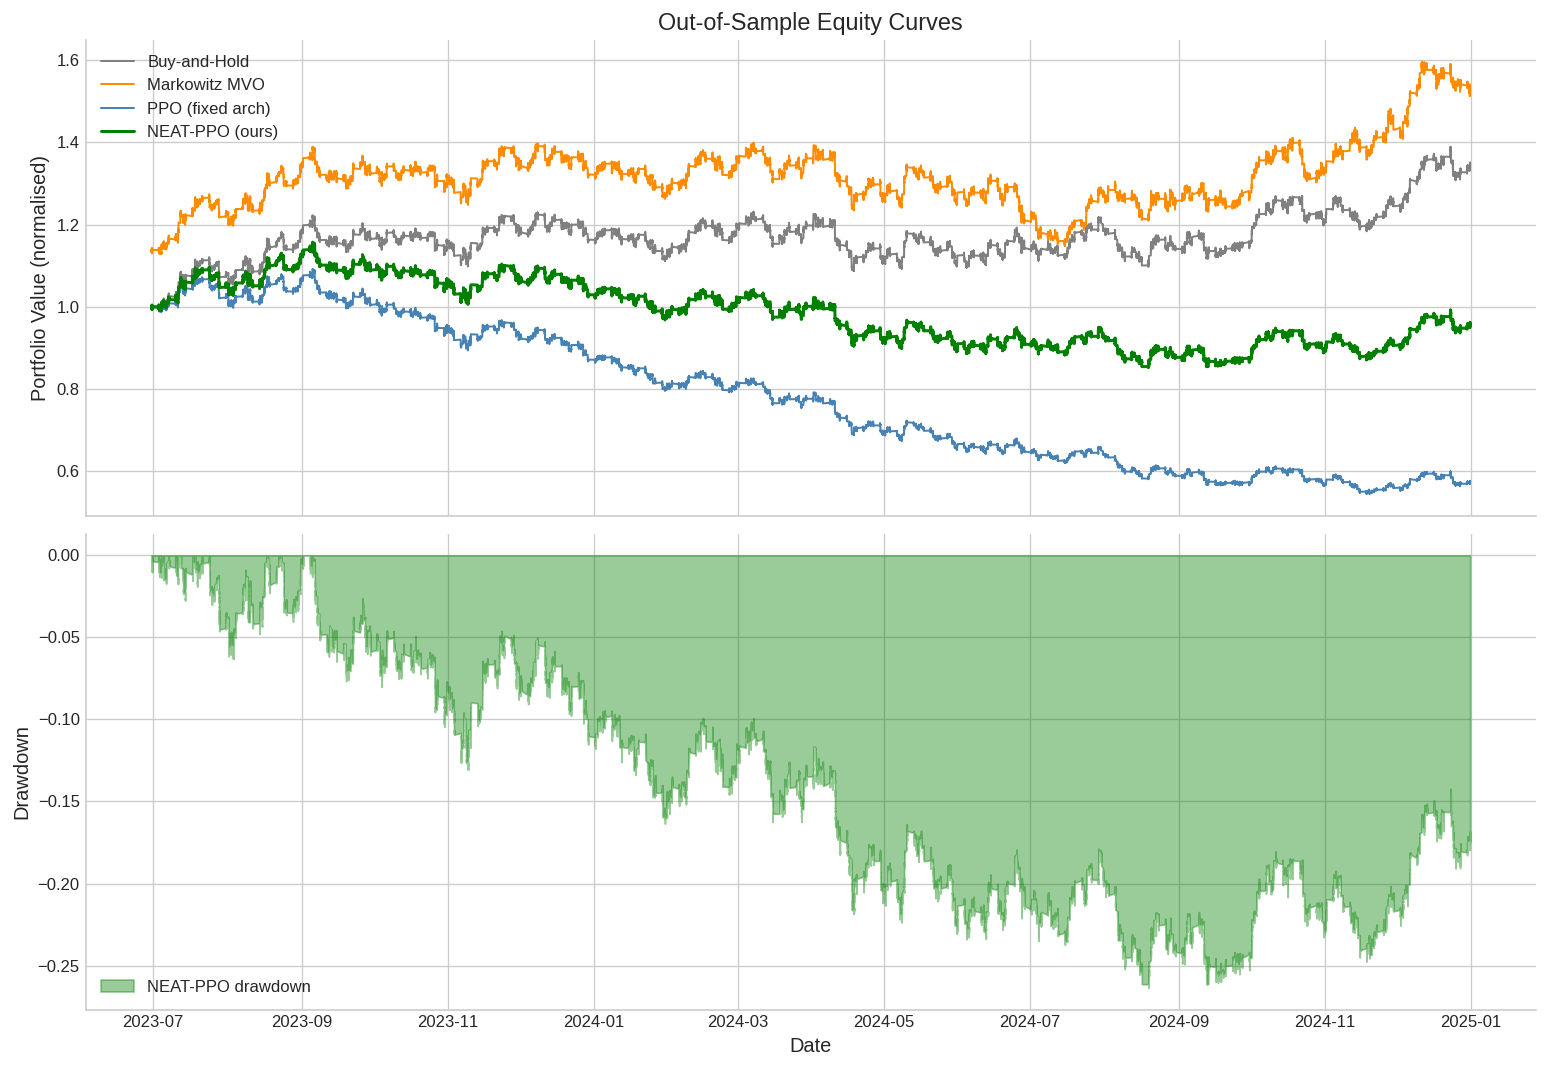

In [ ]:
# ── 10.4  Equity curves ────────────────────────────────────────────────────
min_len = min(len(bnh_equity), len(mvo_equity), len(ppo_equity), len(neat_equity))
test_idx_plot = obs_matrix.index[test_mask][:min_len]

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Top: cumulative equity
ax = axes[0]
ax.plot(test_idx_plot, bnh_equity[:min_len],  lw=1.2, color='gray',       label='Buy-and-Hold')
ax.plot(test_idx_plot, mvo_equity[:min_len],  lw=1.2, color='darkorange',  label='Markowitz MVO')
ax.plot(test_idx_plot, ppo_equity[:min_len],  lw=1.2, color='steelblue',   label='PPO (fixed arch)')
ax.plot(test_idx_plot, neat_equity[:min_len], lw=1.8, color='green',       label='NEAT-PPO (ours)')
ax.set_ylabel('Portfolio Value (normalised)')
ax.set_title('Out-of-Sample Equity Curves')
ax.legend()

# Bottom: drawdown of NEAT-PPO
ax2 = axes[1]
peak_neat = np.maximum.accumulate(neat_equity[:min_len])
dd_neat   = (peak_neat - neat_equity[:min_len]) / (peak_neat + 1e-10)
ax2.fill_between(test_idx_plot, -dd_neat, 0, color='green', alpha=0.4, label='NEAT-PPO drawdown')
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.savefig('fig_equity_curves.png', bbox_inches='tight')
plt.show()

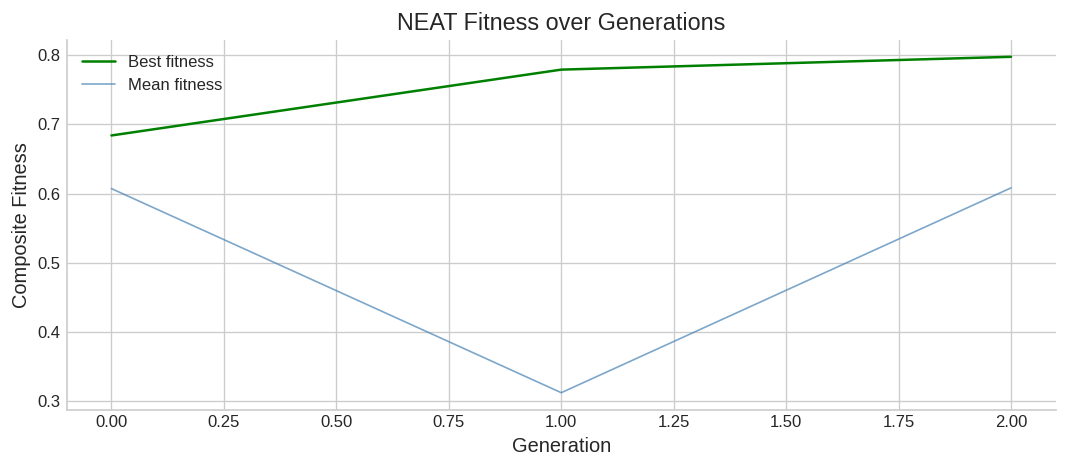

Final best fitness : 0.7973
Best genome nodes  : 16
Best genome conns  : 862
Connection sparsity: 0.8%


In [ ]:
# ── 10.5  NEAT fitness evolution ───────────────────────────────────────────
fit_mean = stats_reporter.get_fitness_mean()
fit_max  = stats_reporter.get_fitness_stat(max)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fit_max,  lw=1.5, color='green',     label='Best fitness')
ax.plot(fit_mean, lw=1.0, color='steelblue', alpha=0.7, label='Mean fitness')
ax.set_xlabel('Generation')
ax.set_ylabel('Composite Fitness')
ax.set_title('NEAT Fitness over Generations')
ax.legend()
plt.tight_layout()
plt.savefig('fig_neat_fitness.png', bbox_inches='tight')
plt.show()

print(f'Final best fitness : {max(fit_max):.4f}')
print(f'Best genome nodes  : {len(best_genome.nodes)}')
print(f'Best genome conns  : {len(best_genome.connections)}')
# Sparsity of best genome
all_w    = [c.weight for c in best_genome.connections.values()]
sparsity = np.mean(np.abs(all_w) < 0.01) if all_w else 0
print(f'Connection sparsity: {sparsity*100:.1f}%')

Summary
Section	What it does
2	Synthetic Nifty-50 OHLCV via correlated GBM + macro variables
3	Feature engineering: momentum, RSI, MACD, vol, rolling z-score normalisation
4	EDA: price history, return distributions, VIX correlation, rolling correlations
5	Walk-forward split: train 2016–2021 / val 2022–Jun2023 / test Jul2023–2024
6	PortfolioEnv Gym environment: softmax weights, 5-bps transaction costs, metrics
7	NEAT outer loop: genome evaluation, composite fitness (Sharpe − DD + sparsity)
8	PPO inner loop via Stable-Baselines3 (shared with LSTM baseline)
9	Baselines: Buy-and-Hold, Markowitz MVO, PPO fixed-arch
10	Out-of-sample results table + equity curves + NEAT fitness plot
To scale up for real training:

Set N_GENERATIONS = 300 in Section 7
Set N_PPO_STEPS = 500_000 in Section 8
Replace synthetic data with real NSE data (Zerodha Kite / NSE archives)
Add multi-processing: neat.ParallelEvaluator for genome fitness evaluation